Running Semgrep on StackOverflow code...
Running Semgrep on ChatGPT code...

=== StackOverflow ===
Total issues: 29
By category: {'java.lang.security.audit.object-deserialization.object-deserialization': 2, 'java.lang.security.audit.command-injection-process-builder.command-injection-process-builder': 1, 'problem-based-packs.insecure-transport.java-stdlib.httpurlconnection-http-request.httpurlconnection-http-request': 1, 'java.lang.security.audit.crypto.unencrypted-socket.unencrypted-socket': 3, 'java.lang.security.audit.cbc-padding-oracle.cbc-padding-oracle': 1, 'java.spring.security.unrestricted-request-mapping.unrestricted-request-mapping': 2, 'java.spring.security.injection.tainted-file-path.tainted-file-path': 2, 'java.lang.security.audit.cookie-missing-httponly.cookie-missing-httponly': 2, 'java.lang.security.audit.cookie-missing-secure-flag.cookie-missing-secure-flag': 3, 'java.spring.security.audit.spring-csrf-disabled.spring-csrf-disabled': 6, 'java.lang.security.audit.xxe.doc

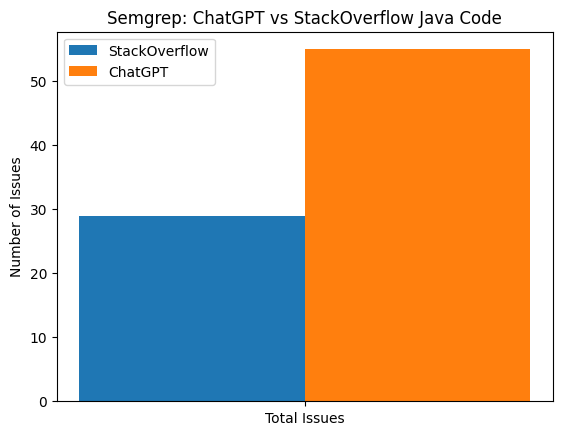

In [ ]:
import pandas as pd
import os
import subprocess
import json
import matplotlib.pyplot as plt

# Install Semgrep if not already installed
!pip install semgrep

# ==== USER CONFIG ====
stackoverflow_csv = "/content/combined_java_SO.csv"
chatgpt_csv = "/content/combined_java_CG.csv"
code_column = "clean_code"  # change to your column name
so_dir = "/content/so_java"
chatgpt_dir = "/content/chatgpt_java"

# Create output directories
os.makedirs(so_dir, exist_ok=True)
os.makedirs(chatgpt_dir, exist_ok=True)

def save_java_files_from_csv(df, directory):
    for i, code in enumerate(df[code_column]):
        file_path = os.path.join(directory, f"snippet_{i}.java")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(str(code) if code else "")

def run_semgrep(directory):
    # Run Semgrep with JSON output
    result = subprocess.run(
        ["semgrep", "--config=auto", "--json", directory],
        capture_output=True,
        text=True
    )
    try:
        data = json.loads(result.stdout)
    except json.JSONDecodeError:
        print("Error decoding Semgrep output")
        return 0, {}

    total_issues = len(data.get("results", []))
    category_counts = {}
    for r in data.get("results", []):
        check_id = r.get("check_id", "unknown")
        category_counts[check_id] = category_counts.get(check_id, 0) + 1
    return total_issues, category_counts

# Read CSVs
so_df = pd.read_csv(stackoverflow_csv)
chatgpt_df = pd.read_csv(chatgpt_csv)

# Save code snippets to .java files
save_java_files_from_csv(so_df, so_dir)
save_java_files_from_csv(chatgpt_df, chatgpt_dir)

# Run Semgrep
print("Running Semgrep on StackOverflow code...")
so_total, so_categories = run_semgrep(so_dir)

print("Running Semgrep on ChatGPT code...")
chatgpt_total, chatgpt_categories = run_semgrep(chatgpt_dir)

# Print results
print("\n=== StackOverflow ===")
print("Total issues:", so_total)
print("By category:", so_categories)

print("\n=== ChatGPT ===")
print("Total issues:", chatgpt_total)
print("By category:", chatgpt_categories)

# Save results to CSV
results_df = pd.DataFrame([
    {"Source": "StackOverflow", "Total Issues": so_total, **so_categories},
    {"Source": "ChatGPT", "Total Issues": chatgpt_total, **chatgpt_categories}
])
results_csv_path = "/content/semgrep_java_results.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"\nResults saved to {results_csv_path}")

# Plot comparison
labels = ['Total Issues']
so_counts = [so_total]
chatgpt_counts = [chatgpt_total]

x = range(len(labels))
plt.bar(x, so_counts, width=0.4, label='StackOverflow')
plt.bar([p+0.4 for p in x], chatgpt_counts, width=0.4, label='ChatGPT')

plt.xticks([p+0.2 for p in x], labels)
plt.ylabel('Number of Issues')
plt.title('Semgrep: ChatGPT vs StackOverflow Java Code')
plt.legend()
plt.show()


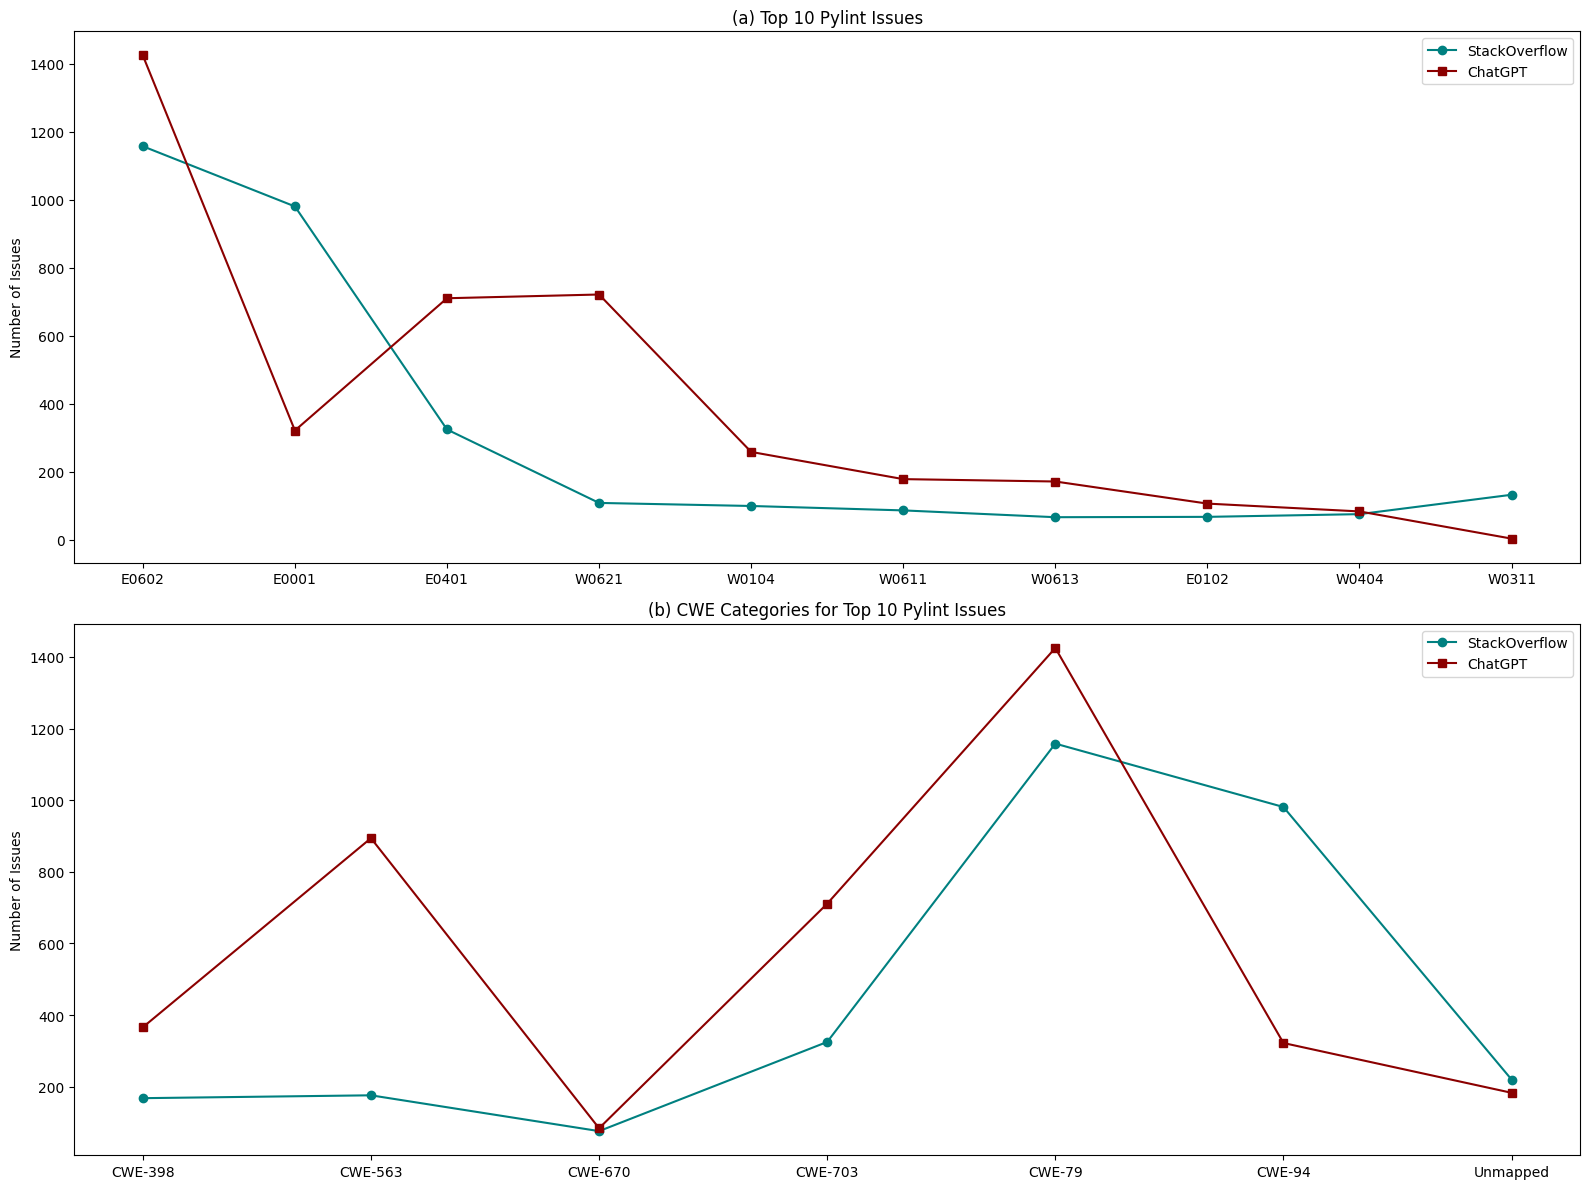


=== Top 10 Pylint Issues Table ===
  Category  StackOverflow  ChatGPT              Description
0    E0602           1158     1425       Undefined variable
1    E0001            981      322             Syntax error
2    E0401            325      711             Import error
3    W0621            109      722      Redefining variable
4    W0104            100      259  Statement has no effect
5    W0611             87      179                  Unknown
6    W0613             67      172          Unused argument
7    E0102             68      107       Function redefined
8    W0404             76       84        Reimported module
9    W0311            133        4                  Unknown

=== CWE Categories Table ===
                                                 CWE  StackOverflow  ChatGPT  \
0                        CWE-398: Code Quality Issue            168      366   
1                           CWE-563: Unused Variable            176      894   
2      CWE-670: Improper Cleanup o

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
top10_df = pd.read_csv("pylint_top10_results.csv")
cwe_df = pd.read_csv("pylint_top10_with_cwe.csv")

# Aggregate CWE
cwe_grouped = cwe_df.groupby("CWE")[["StackOverflow","ChatGPT"]].sum().reset_index()

# Optional: Add descriptions (example mapping, extend as needed)
pylint_descriptions = {
    "E0602": "Undefined variable",
    "E0401": "Import error",
    "E0001": "Syntax error",
    "W0621": "Redefining variable",
    "W0612": "Unused variable",
    "W0104": "Statement has no effect",
    "W0613": "Unused argument",
    "E1101": "Attribute not found",
    "W0404": "Reimported module",
    "E0102": "Function redefined",
}

# Add description column
top10_df["Description"] = top10_df["Category"].map(lambda x: pylint_descriptions.get(x, "Unknown"))
cwe_grouped["Description"] = cwe_grouped["CWE"].map(lambda x: pylint_descriptions.get(x.split(":")[0], "Unknown"))

# Colors
so_color = "#008080"
gpt_color = "#8B0000"

# === Plot combined figure (2 rows) ===
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharey=False)

# (a) Top 10 Pylint Issues - Line Plot
ax = axes[0]
categories = top10_df["Category"]
ax.plot(categories, top10_df["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, top10_df["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_ylabel("Number of Issues")
ax.set_title("(a) Top 10 Pylint Issues")
ax.legend()

# (b) CWE Categories - Line Plot
ax = axes[1]
categories = cwe_grouped["CWE"].apply(lambda x: x.split(":")[0])  # only code for X-axis
ax.plot(categories, cwe_grouped["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, cwe_grouped["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_ylabel("Number of Issues")
ax.set_title("(b) CWE Categories for Top 10 Pylint Issues")
ax.legend()

plt.tight_layout()
plt.savefig("pylint_combined_line.png", dpi=300)
plt.show()

# === Print tabular results ===
print("\n=== Top 10 Pylint Issues Table ===")
print(top10_df[["Category","StackOverflow","ChatGPT","Description"]])

print("\n=== CWE Categories Table ===")
print(cwe_grouped[["CWE","StackOverflow","ChatGPT","Description"]])


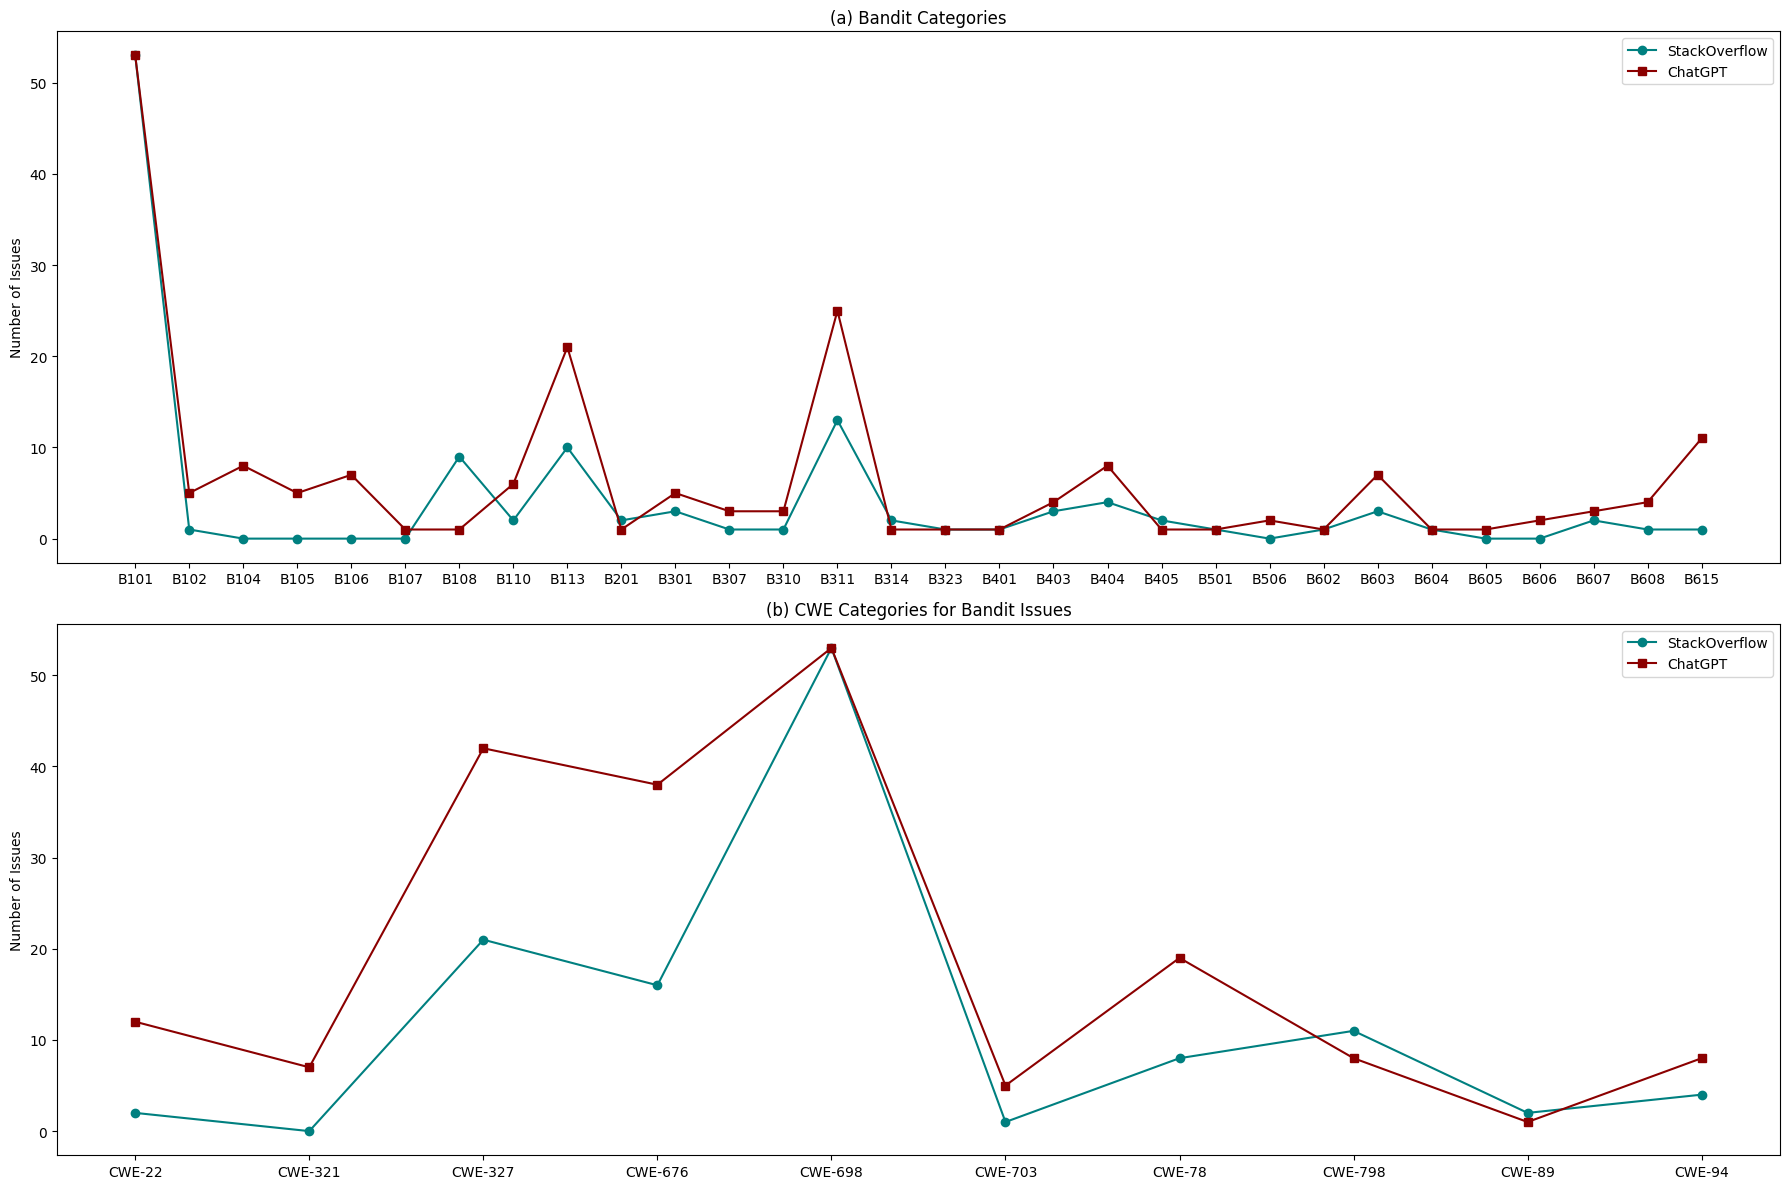


=== Bandit Normal Categories Table ===
   Category  StackOverflow  ChatGPT                        Description
0      B101             53       53                        Assert used
1      B102              1        5                          Exec used
2      B104              0        8             Insecure hash function
3      B105              0        5             Weak cryptographic key
4      B106              0        7                 Hardcoded password
5      B107              0        1              Hardcoded credentials
6      B108              9        1                      Hardcoded SQL
7      B110              2        6                Hardcoded temp file
8      B113             10       21           Requests without timeout
9      B201              2        1                      SQL injection
10     B301              3        5                       Pickle.loads
11     B307              1        3                          Eval used
12     B310              1        3  

In [ ]:
# Load Bandit data
normal_df = pd.read_csv("bandit_comparison_results.csv")
cwe_df = pd.read_csv("bandit_cwe_comparison.csv")

# Optional: Add Bandit descriptions (extend as needed)
bandit_descriptions = {
    "B101": "Assert used",
    "B102": "Exec used",
    "B103": "Bad file permissions",
    "B104": "Insecure hash function",
    "B105": "Weak cryptographic key",
    "B106": "Hardcoded password",
    "B107": "Hardcoded credentials",
    "B108": "Hardcoded SQL",
    "B110": "Hardcoded temp file",
    "B113": "Requests without timeout",
    "B201": "SQL injection",
    "B301": "Pickle.loads",
    "B307": "Eval used",
    "B310": "Insecure cipher",
    "B311": "Random not secure",
    "B314": "Insecure XML parser",
    "B323": "Unsafe temp file creation",
    "B401": "Cryptography issues",
    "B403": "PyCrypto used",
    "B404": "Subprocess without shell=False",
    "B405": "XML parsing issues",
    "B501": "SSL without cert validation",
    "B502": "SSL without cert validation",
    "B503": "SSL without cert validation",
    "B504": "SSL without cert validation",
    "B505": "SSL without cert validation",
    "B506": "SSL without cert validation",
    "B602": "Subprocess with shell=True",
    "B603": "Subprocess without shell=False",
    "B604": "OS system call",
    "B605": "Popen with shell=True",
    "B606": "Startfile path injection",
    "B607": "Tarfile.extractall path traversal",
    "B608": "YAML load unsafe",
    "B615": "Open() with untrusted input",
}

normal_df["Description"] = normal_df["Category"].map(lambda x: bandit_descriptions.get(x, "Unknown"))
cwe_df["Description"] = cwe_df["CWE"].map(lambda x: bandit_descriptions.get(x.split("-")[0], "Unknown"))

# Colors
so_color = "#008080"
gpt_color = "#8B0000"

# Combined figure
fig, axes = plt.subplots(2,1, figsize=(18,12), sharey=False)

# (a) Normal categories
ax = axes[0]
categories = normal_df["Category"]
ax.plot(categories, normal_df["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, normal_df["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_ylabel("Number of Issues")
ax.set_title("(a) Bandit Categories")
ax.legend()

# (b) CWE categories - only code for X-axis
ax = axes[1]
categories = cwe_df["CWE"].apply(lambda x: x)  # already like CWE-xxx
ax.plot(categories, cwe_df["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, cwe_df["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_ylabel("Number of Issues")
ax.set_title("(b) CWE Categories for Bandit Issues")
ax.legend()

plt.tight_layout()
plt.savefig("bandit_combined_line.png", dpi=300)
plt.show()

# Print tabular results
print("\n=== Bandit Normal Categories Table ===")
print(normal_df[["Category","StackOverflow","ChatGPT","Description"]])

print("\n=== Bandit CWE Categories Table ===")
print(cwe_df[["CWE","StackOverflow","ChatGPT","Description"]])


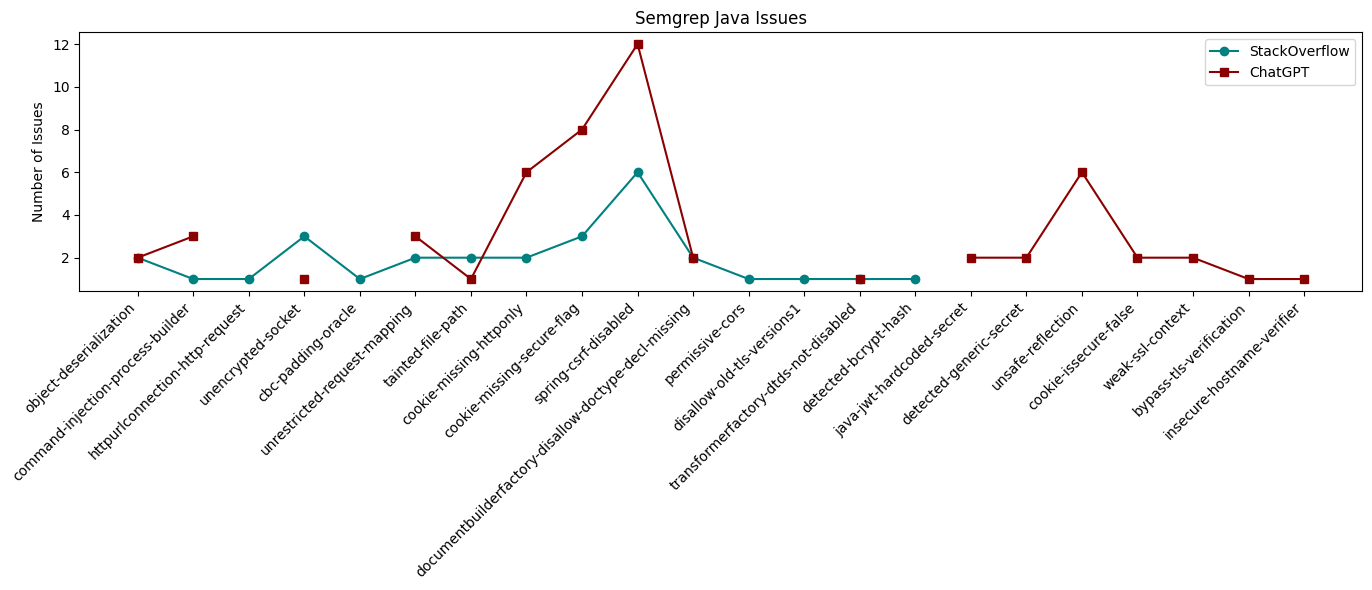

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
results_df = pd.read_csv("semgrep_java_results.csv")

# Separate counts
so_row = results_df[results_df["Source"]=="StackOverflow"].iloc[0]
gpt_row = results_df[results_df["Source"]=="ChatGPT"].iloc[0]

# Extract categories
categories = [c for c in results_df.columns if c not in ["Source", "Total Issues"]]
so_counts = [so_row[c] for c in categories]
gpt_counts = [gpt_row[c] for c in categories]

# Shorten labels: take last part after dot
short_labels = [c.split('.')[-1] for c in categories]

# Colors
so_color = "#008080"
gpt_color = "#8B0000"

# === Line Plot ===
plt.figure(figsize=(14,6))
plt.plot(short_labels, so_counts, marker="o", color=so_color, label="StackOverflow")
plt.plot(short_labels, gpt_counts, marker="s", color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Issues")
plt.title("Semgrep Java Issues")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_3075733/1945459411.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=45, ha="right")
/tmp/ipykernel_3075733/1945459411.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=45, ha="right")


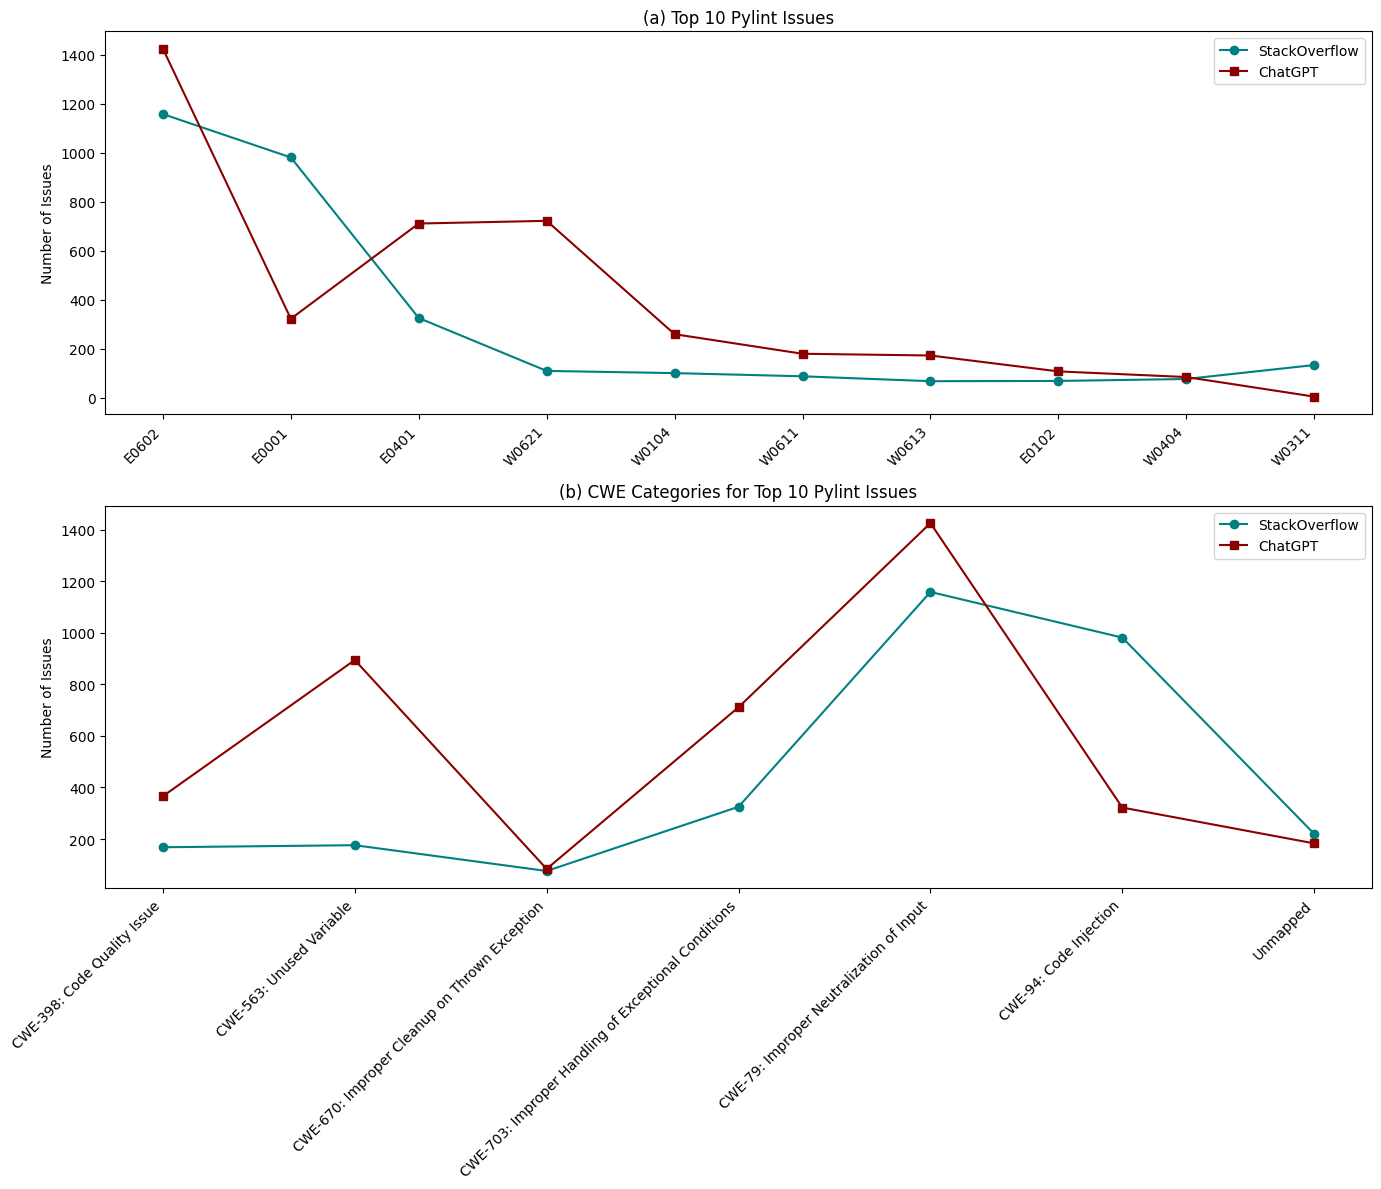

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSVs
top10_df = pd.read_csv("pylint_top10_results.csv")
cwe_df = pd.read_csv("pylint_top10_with_cwe.csv")

# Aggregate CWE
cwe_grouped = cwe_df.groupby("CWE")[["StackOverflow","ChatGPT"]].sum().reset_index()

# Colors
so_color = "#008080"
gpt_color = "#8B0000"

# === Create combined figure (2 rows, 1 column) ===
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=False)

# (a) Top 10 Categories - Line Plot
ax = axes[0]
categories = top10_df["Category"]
ax.plot(categories, top10_df["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, top10_df["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_ylabel("Number of Issues")
ax.set_title("(a) Top 10 Pylint Issues")
ax.legend()

# (b) CWE Categories - Line Plot
ax = axes[1]
categories = cwe_grouped["CWE"]
ax.plot(categories, cwe_grouped["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, cwe_grouped["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_ylabel("Number of Issues")
ax.set_title("(b) CWE Categories for Top 10 Pylint Issues")
ax.legend()

plt.tight_layout()
plt.savefig("pylint_combined_line.png", dpi=300)
plt.show()


/tmp/ipykernel_3075733/137415595.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=45, ha="right")
/tmp/ipykernel_3075733/137415595.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=45, ha="right")


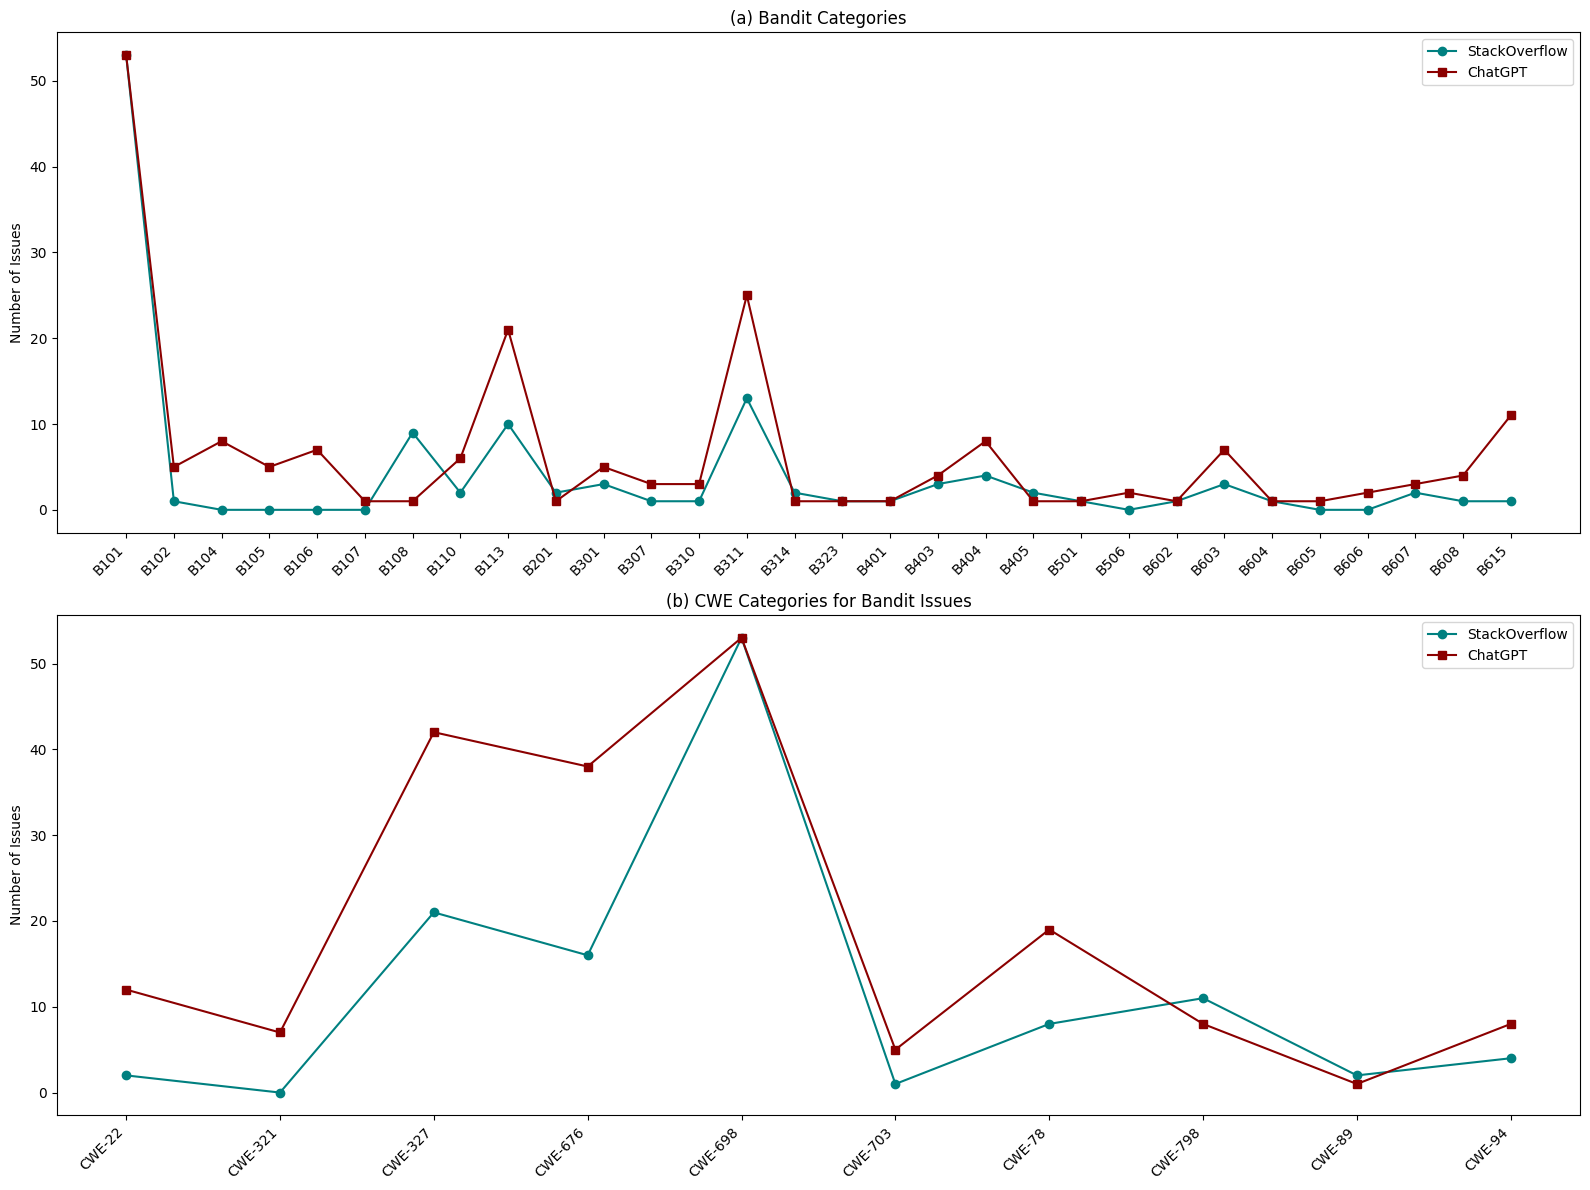

In [ ]:
# Load CSVs
normal_df = pd.read_csv("bandit_comparison_results.csv")
cwe_df = pd.read_csv("bandit_cwe_comparison.csv")

# Colors
so_color = "#008080"
gpt_color = "#8B0000"

# Create combined figure (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharey=False)

# (a) Normal Bandit categories - Line Plot
ax = axes[0]
categories = normal_df["Category"]
ax.plot(categories, normal_df["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, normal_df["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_ylabel("Number of Issues")
ax.set_title("(a) Bandit Categories")
ax.legend()

# (b) CWE Categories - Line Plot
ax = axes[1]
categories = cwe_df["CWE"]
ax.plot(categories, cwe_df["StackOverflow"], marker="o", color=so_color, label="StackOverflow")
ax.plot(categories, cwe_df["ChatGPT"], marker="s", color=gpt_color, label="ChatGPT")
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_ylabel("Number of Issues")
ax.set_title("(b) CWE Categories for Bandit Issues")
ax.legend()

plt.tight_layout()
plt.savefig("bandit_combined_line.png", dpi=300)
plt.show()


  Using cached bandit-1.8.6-py3-none-any.whl.metadata (6.9 kB)
  Using cached stevedore-5.4.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached pbr-7.0.0-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached bandit-1.8.6-py3-none-any.whl (133 kB)
Using cached stevedore-5.4.1-py3-none-any.whl (49 kB)
Using cached pbr-7.0.0-py2.py3-none-any.whl (125 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [bandit]2m4/6 [rich]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Running Bandit on StackOverflow code...
Running Bandit on ChatGPT code...

=== Total Issues ===
StackOverflow: 118
ChatGPT: 193

=== Category-wise Issues ===
StackOverflow: {'B311': 13, 'B113': 10, 'B101': 53, 'B323': 1, 'B404': 4, 'B607': 2, 'B603': 3, 'B307': 1, 'B401': 1, 'B604': 1, 'B102': 1, 'B201': 2, 'B301': 3, 'B608': 1, 'B108': 9, 'B110': 2, 'B403': 3, 'B405': 2, 'B314': 2, 'B602': 1, 'B310': 1, 'B615': 1, 'B501': 1}
ChatGPT: {'B311': 25, 'B101': 53, 'B32

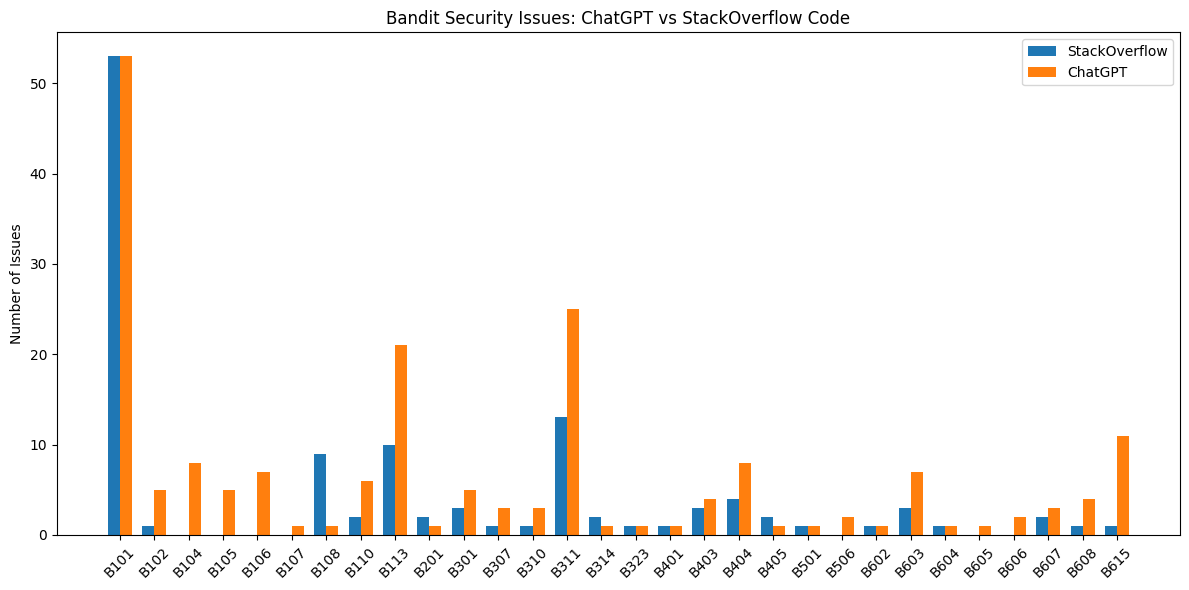

In [ ]:
# 1️⃣ Install Bandit
!pip install bandit

import pandas as pd
import subprocess
import tempfile
import json
import matplotlib.pyplot as plt
from collections import Counter
import sys

# 2️⃣ File paths (upload your CSVs to Colab first or mount Google Drive)
so_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_python_SO.csv"
gpt_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_python_CG.csv"

# 3️⃣ Load CSVs
so_df = pd.read_csv(so_file)
gpt_df = pd.read_csv(gpt_file)

def run_bandit_on_code(code_snippet):
    """Run Bandit on a single code snippet and return issue codes found."""
    # Write code to temp file
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as tmp_file:
        tmp_file.write(code_snippet)
        tmp_path = tmp_file.name

    # Run bandit via Python module to avoid PATH issues
    result = subprocess.run(
        [sys.executable, "-m", "bandit", "-f", "json", "-q", tmp_path],
        capture_output=True,
        text=True
    )

    try:
        output = json.loads(result.stdout)
        issue_codes = [issue["test_id"] for issue in output.get("results", [])]
    except json.JSONDecodeError:
        issue_codes = []

    return issue_codes

def analyze_dataframe(df):
    """Analyze all rows of a DataFrame with Bandit and return counts."""
    all_issues = []
    for _, row in df.iterrows():
        code = row["clean_code"] if not pd.isna(row["clean_code"]) else ""
        issues = run_bandit_on_code(code)
        all_issues.extend(issues)

    total_issues = len(all_issues)
    category_counts = Counter(all_issues)
    return total_issues, category_counts

# 4️⃣ Analyze both datasets
print("Running Bandit on StackOverflow code...")
so_total, so_category_counts = analyze_dataframe(so_df)

print("Running Bandit on ChatGPT code...")
gpt_total, gpt_category_counts = analyze_dataframe(gpt_df)

# 5️⃣ Print results
print("\n=== Total Issues ===")
print(f"StackOverflow: {so_total}")
print(f"ChatGPT: {gpt_total}")

print("\n=== Category-wise Issues ===")
print("StackOverflow:", dict(so_category_counts))
print("ChatGPT:", dict(gpt_category_counts))

# 6️⃣ Save results to CSV
results_df = pd.DataFrame({
    "Category": sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys())),
    "StackOverflow": [so_category_counts.get(cat, 0) for cat in sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys()))],
    "ChatGPT": [gpt_category_counts.get(cat, 0) for cat in sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys()))]
})
results_df.to_csv("bandit_comparison_results.csv", index=False)
print("\nSaved category-wise comparison to bandit_comparison_results.csv")

# 7️⃣ Plot comparison
categories = results_df["Category"]
so_counts = results_df["StackOverflow"]
gpt_counts = results_df["ChatGPT"]

plt.figure(figsize=(12, 6))
bar_width = 0.35
x = range(len(categories))

plt.bar(x, so_counts, width=bar_width, label="StackOverflow")
plt.bar([i + bar_width for i in x], gpt_counts, width=bar_width, label="ChatGPT")

plt.xticks([i + bar_width / 2 for i in x], categories, rotation=45)
plt.ylabel("Number of Issues")
plt.title("Bandit Security Issues: ChatGPT vs StackOverflow Code")
plt.legend()
plt.tight_layout()
plt.show()


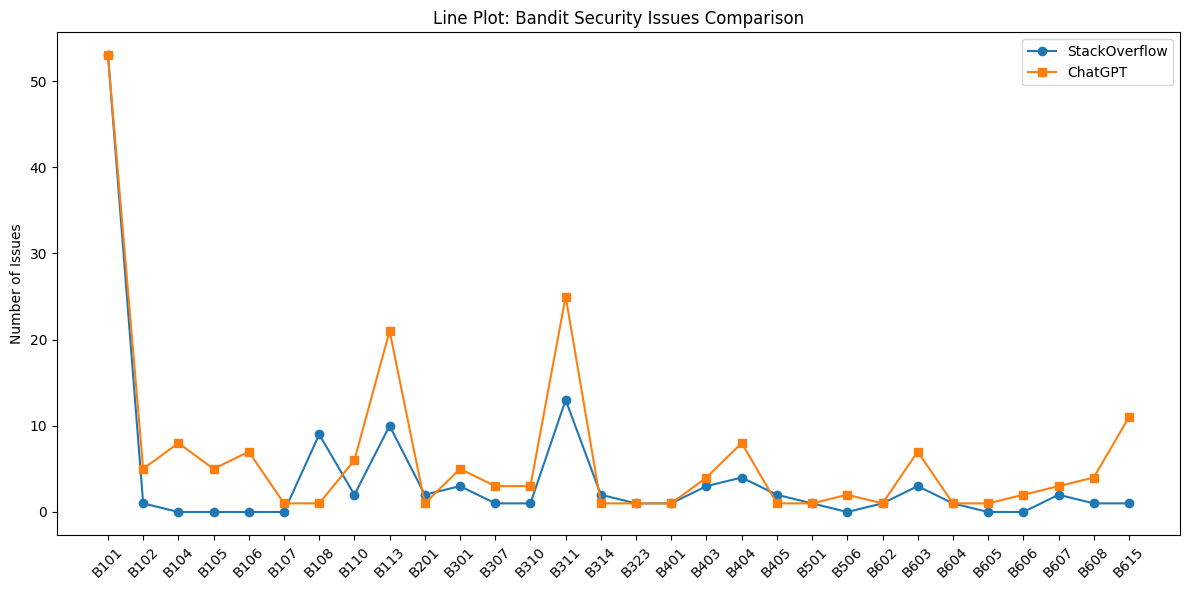

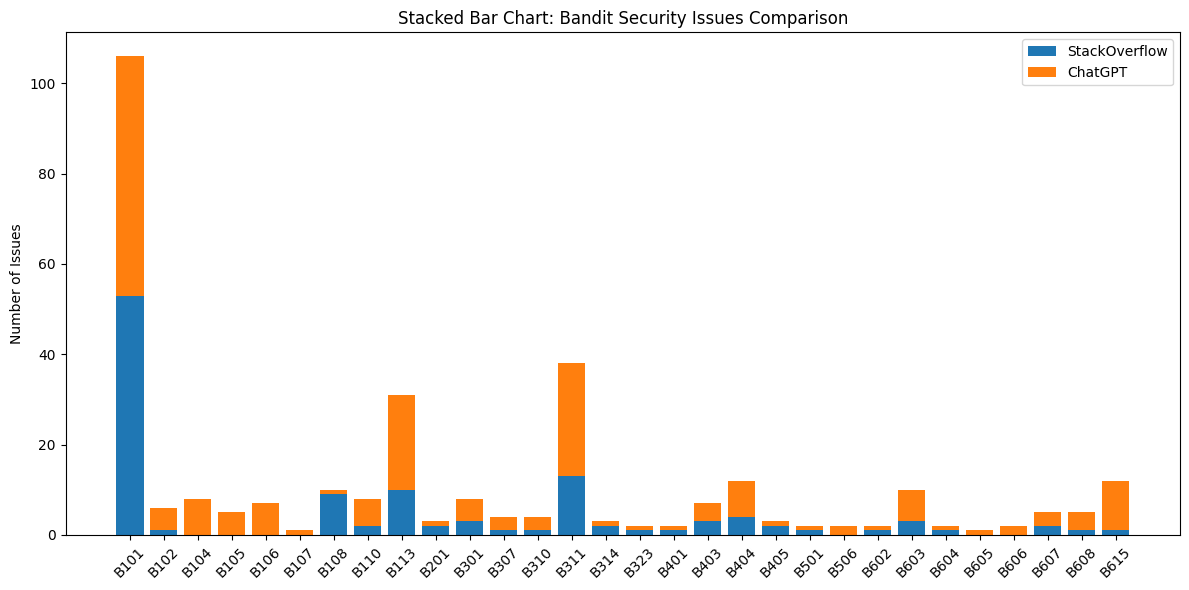

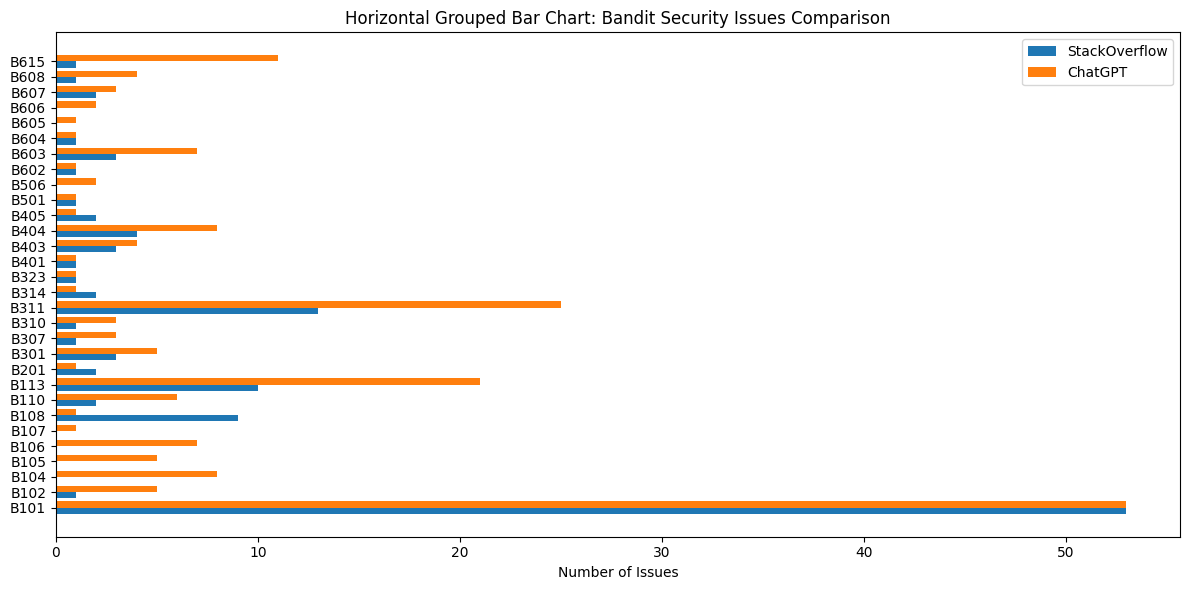

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Load saved CSV
results_df = pd.read_csv("bandit_comparison_results.csv")

categories = results_df["Category"]
so_counts = results_df["StackOverflow"]
gpt_counts = results_df["ChatGPT"]

# 2️⃣ Line Plot
plt.figure(figsize=(12,6))
plt.plot(categories, so_counts, marker="o", label="StackOverflow")
plt.plot(categories, gpt_counts, marker="s", label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Line Plot: Bandit Security Issues Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 3️⃣ Stacked Bar Chart
plt.figure(figsize=(12,6))
plt.bar(categories, so_counts, label="StackOverflow")
plt.bar(categories, gpt_counts, bottom=so_counts, label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Stacked Bar Chart: Bandit Security Issues Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 4️⃣ Grouped Horizontal Bar Chart
plt.figure(figsize=(12,6))
bar_width = 0.4
y = range(len(categories))

plt.barh([i - bar_width/2 for i in y], so_counts, height=bar_width, label="StackOverflow")
plt.barh([i + bar_width/2 for i in y], gpt_counts, height=bar_width, label="ChatGPT")

plt.yticks(y, categories)
plt.xlabel("Number of Issues")
plt.title("Horizontal Grouped Bar Chart: Bandit Security Issues Comparison")
plt.legend()
plt.tight_layout()
plt.show()


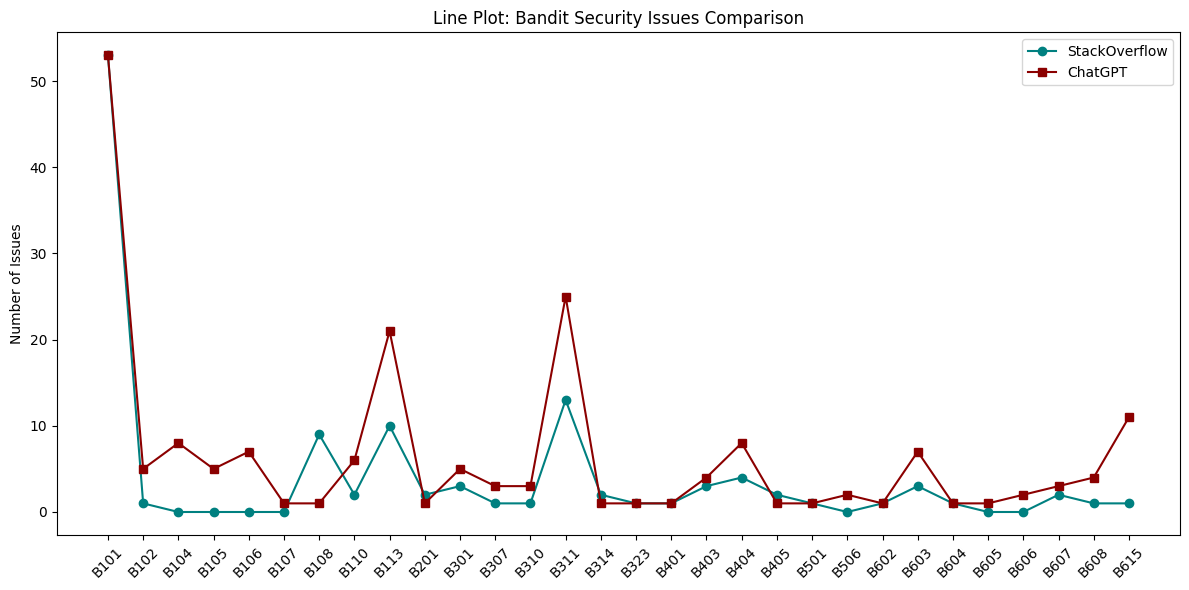

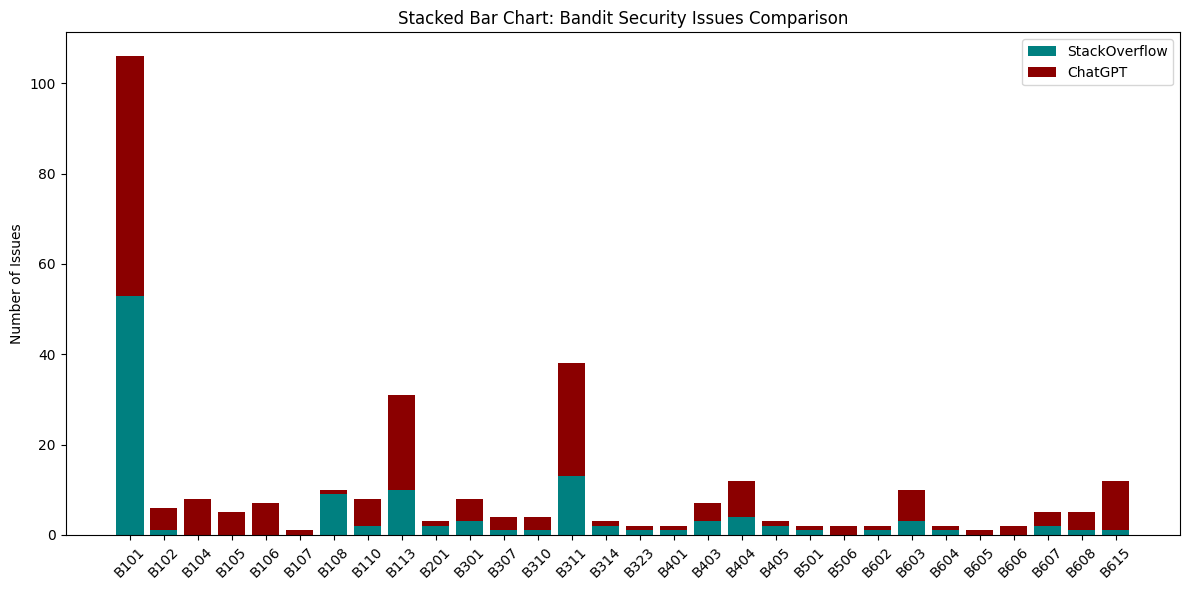

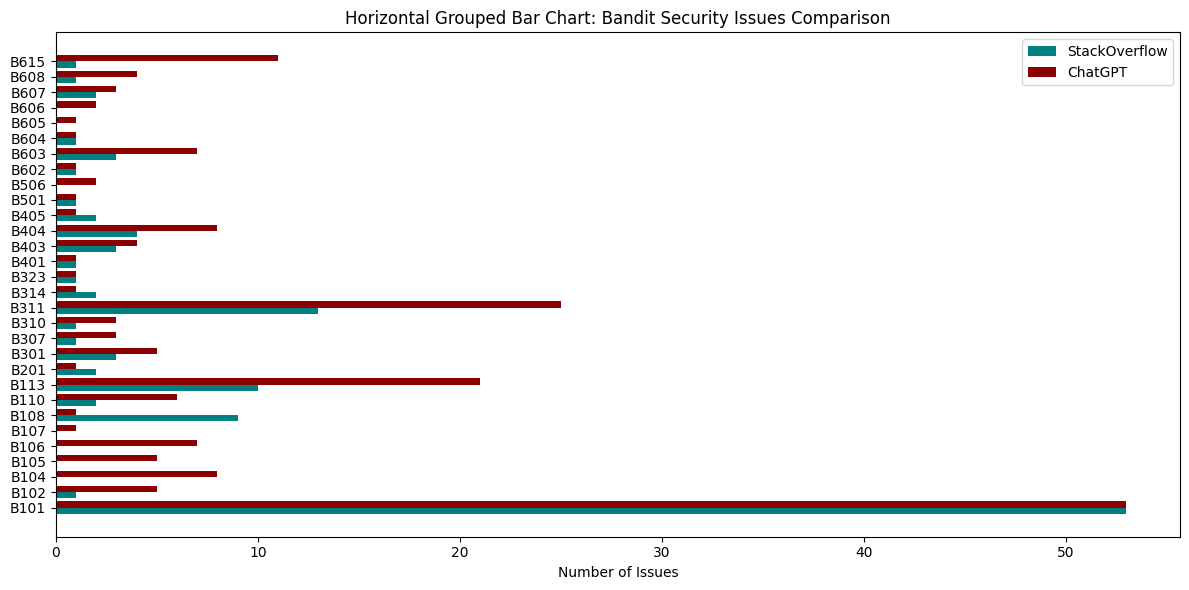

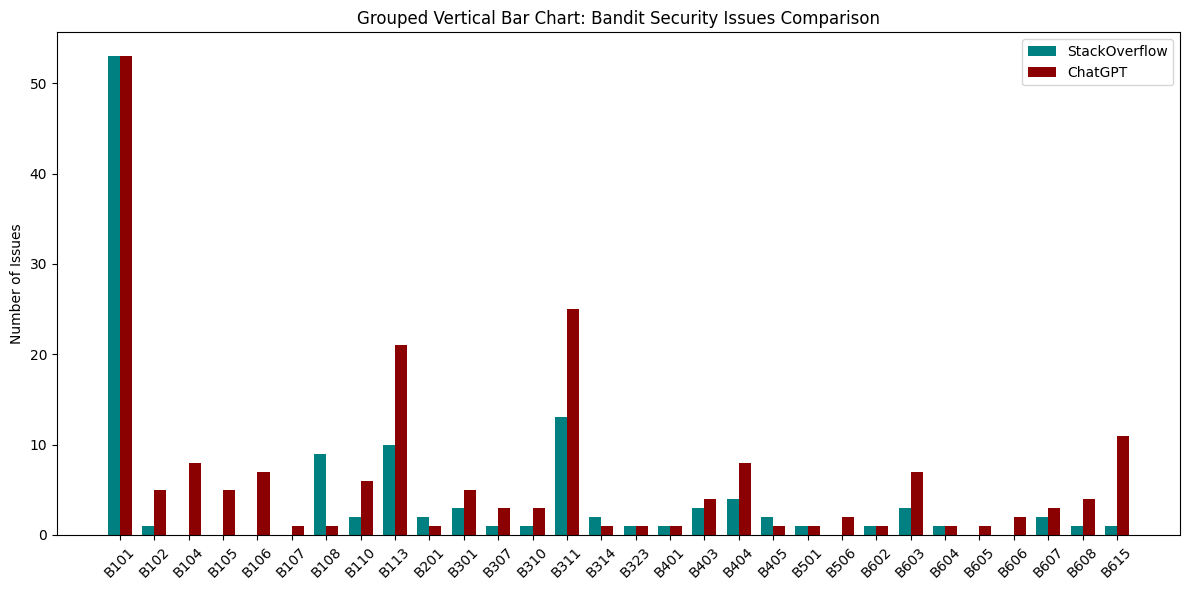

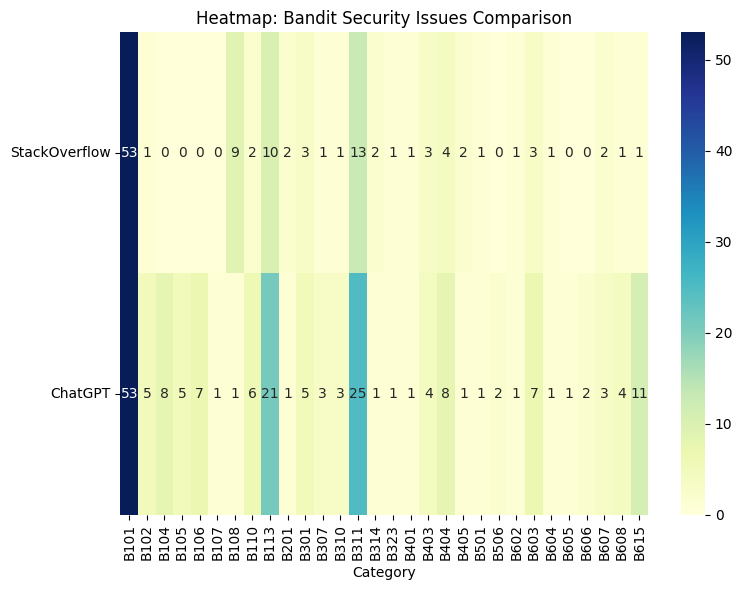

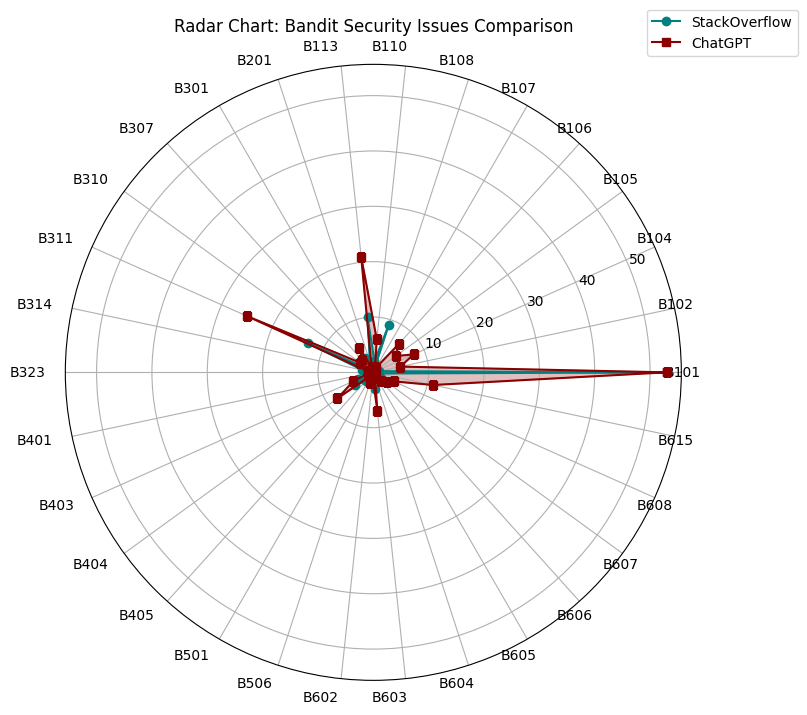

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Load saved CSV
results_df = pd.read_csv("bandit_comparison_results.csv")

categories = results_df["Category"]
so_counts = results_df["StackOverflow"]
gpt_counts = results_df["ChatGPT"]

# Custom colors
so_color = "#008080"   # teal
gpt_color = "#8B0000"  # dark red

# 2️⃣ Line Plot
plt.figure(figsize=(12,6))
plt.plot(categories, so_counts, marker="o", color=so_color, label="StackOverflow")
plt.plot(categories, gpt_counts, marker="s", color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Line Plot: Bandit Security Issues Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 3️⃣ Stacked Bar Chart
plt.figure(figsize=(12,6))
plt.bar(categories, so_counts, color=so_color, label="StackOverflow")
plt.bar(categories, gpt_counts, bottom=so_counts, color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Stacked Bar Chart: Bandit Security Issues Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 4️⃣ Horizontal Grouped Bar Chart
plt.figure(figsize=(12,6))
bar_width = 0.4
y = np.arange(len(categories))

plt.barh(y - bar_width/2, so_counts, height=bar_width, color=so_color, label="StackOverflow")
plt.barh(y + bar_width/2, gpt_counts, height=bar_width, color=gpt_color, label="ChatGPT")

plt.yticks(y, categories)
plt.xlabel("Number of Issues")
plt.title("Horizontal Grouped Bar Chart: Bandit Security Issues Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 5️⃣ Grouped Vertical Bar Chart
plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(categories))

plt.bar(x - bar_width/2, so_counts, width=bar_width, color=so_color, label="StackOverflow")
plt.bar(x + bar_width/2, gpt_counts, width=bar_width, color=gpt_color, label="ChatGPT")

plt.xticks(x, categories, rotation=45)
plt.ylabel("Number of Issues")
plt.title("Grouped Vertical Bar Chart: Bandit Security Issues Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 6️⃣ Heatmap (Category vs Tool)
plt.figure(figsize=(8,6))
heatmap_data = results_df.set_index("Category")[["StackOverflow","ChatGPT"]].T
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Heatmap: Bandit Security Issues Comparison")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7️⃣ Radar Chart (Spider Plot)
labels = categories
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
so_values = so_counts.tolist()
gpt_values = gpt_counts.tolist()

# Close the loop
so_values += so_values[:1]
gpt_values += gpt_values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
ax.plot(angles, so_values, color=so_color, marker="o", label="StackOverflow")
ax.fill(angles, so_values, color=so_color, alpha=0.25)
ax.plot(angles, gpt_values, color=gpt_color, marker="s", label="ChatGPT")
ax.fill(angles, gpt_values, color=gpt_color, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_title("Radar Chart: Bandit Security Issues Comparison")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.show()


In [ ]:
import pandas as pd
import subprocess
import tempfile
import json
import sys

# === Utility to run Bandit on a snippet and return details ===
def run_bandit_on_code(code_snippet):
    """Run Bandit on a single code snippet and return detailed issues."""
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as tmp_file:
        tmp_file.write(code_snippet)
        tmp_path = tmp_file.name

    result = subprocess.run(
        [sys.executable, "-m", "bandit", "-f", "json", "-q", tmp_path],
        capture_output=True,
        text=True
    )

    issues = []
    try:
        output = json.loads(result.stdout)
        for issue in output.get("results", []):
            issues.append({
                "test_id": issue["test_id"],              # e.g. B602
                "description": issue["issue_text"],       # Human-readable description
                "line_number": issue.get("line_number"),  # Starting line
                "line_range": issue.get("line_range"),    # Specific lines (if available)
            })
    except json.JSONDecodeError:
        pass

    return issues

# === Analyze DataFrame and collect detailed results ===
def analyze_dataframe(df, source_name):
    """Analyze all rows of a DataFrame with Bandit and return a detailed DataFrame."""
    records = []
    for idx, row in df.iterrows():
        code = row["clean_code"] if not pd.isna(row["clean_code"]) else ""
        issues = run_bandit_on_code(code)

        for issue in issues:
            records.append({
                "Source": source_name,
                "Row_ID": idx,
                "Error_Code": issue["test_id"],
                "Description": issue["description"],
                "Full_Snippet": code,
                "Error_Lines": issue["line_range"] if issue["line_range"] else issue["line_number"]
            })

    return pd.DataFrame(records)

# === Run for SO and ChatGPT ===
so_results = analyze_dataframe(so_df, "StackOverflow")
gpt_results = analyze_dataframe(gpt_df, "ChatGPT")

# Combine into one DataFrame
detailed_results = pd.concat([so_results, gpt_results], ignore_index=True)

# Save full details
detailed_results.to_csv("bandit_detailed_results.csv", index=False)

print("Saved detailed results with description, snippets, and error lines -> bandit_detailed_results.csv")


Saved detailed results with description, snippets, and error lines -> bandit_detailed_results.csv


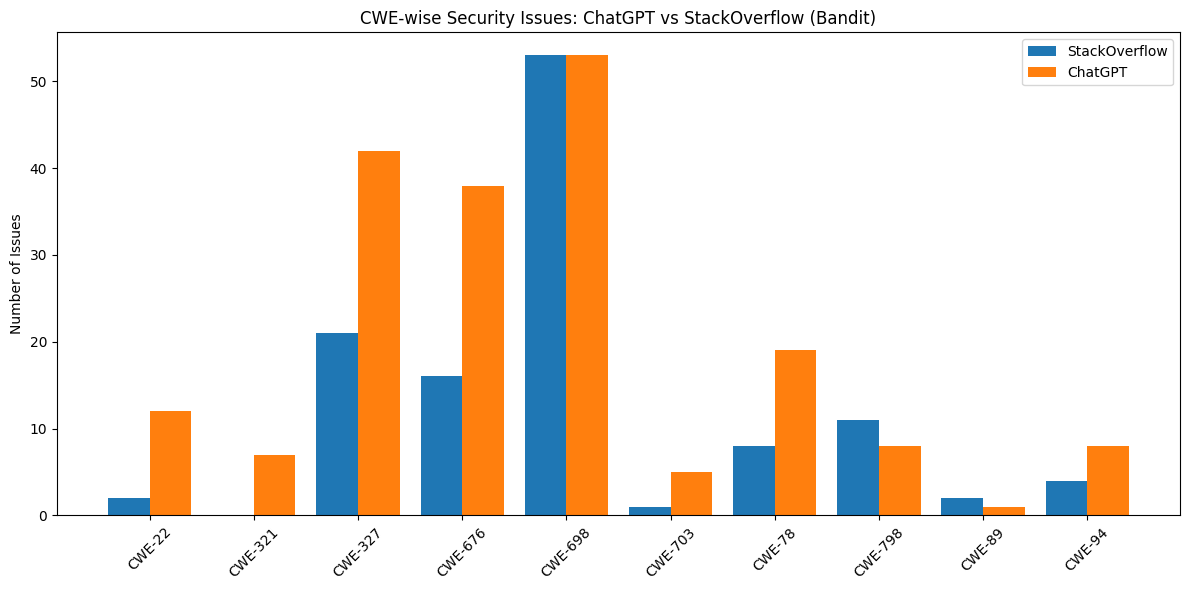

✅ CWE mapping done. Results saved to 'bandit_cwe_comparison.csv' and plot saved to 'bandit_cwe_comparison.png'


In [ ]:
import pandas as pd

# === Step 1: Load the saved Bandit comparison CSV ===
df = pd.read_csv("bandit_comparison_results.csv")

# The file is assumed to have columns: "Category", "StackOverflow", "ChatGPT"
# Example:
# Category,StackOverflow,ChatGPT
# B101,53,53
# B311,13,25
# ...

# === Step 2: CWE mapping dictionary ===
bandit_to_cwe = {
    "B101": "CWE-698",   # assert statement used
    "B102": "CWE-703",   # exec used
    "B103": "CWE-20",    # bad file permissions
    "B104": "CWE-676",   # insecure hash function
    "B105": "CWE-327",   # weak cryptographic key
    "B106": "CWE-321",   # hardcoded password
    "B107": "CWE-798",   # hardcoded credentials
    "B108": "CWE-798",   # hardcoded SQL queries
    "B110": "CWE-798",   # hardcoded temporary file
    "B113": "CWE-676",   # requests without timeout
    "B201": "CWE-89",    # SQL injection
    "B301": "CWE-94",    # pickle.loads
    "B307": "CWE-94",    # eval used
    "B310": "CWE-327",   # insecure cipher
    "B311": "CWE-327",   # random not secure
    "B314": "CWE-327",   # insecure XML parser
    "B323": "CWE-22",    # unsafe temp file creation
    "B401": "CWE-327",   # cryptography issues
    "B403": "CWE-327",   # pycrypto used
    "B404": "CWE-676",   # subprocess without shell=False
    "B405": "CWE-676",   # xml.etree.cElementTree
    "B501": "CWE-327",   # ssl without cert validation
    "B502": "CWE-327",
    "B503": "CWE-327",
    "B504": "CWE-327",
    "B505": "CWE-327",
    "B506": "CWE-327",
    "B602": "CWE-78",    # subprocess with shell=True
    "B603": "CWE-78",    # subprocess without shell=False
    "B604": "CWE-78",    # os.system
    "B605": "CWE-78",    # popen with shell=True
    "B606": "CWE-78",    # startfile path injection
    "B607": "CWE-78",    # tarfile.extractall path traversal
    "B608": "CWE-78",    # yaml.load unsafe
    "B615": "CWE-22",    # open() with untrusted input
}

# === Step 3: Map Bandit category to CWE ===
df["CWE"] = df["Category"].map(bandit_to_cwe).fillna("Unknown")

# === Step 4: Group by CWE and sum counts ===
cwe_summary = df.groupby("CWE")[["StackOverflow", "ChatGPT"]].sum().reset_index()

# === Step 5: Save CWE-wise summary ===
cwe_summary.to_csv("bandit_cwe_comparison.csv", index=False)

# === Step 6: Plot CWE-wise comparison ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
x = range(len(cwe_summary))
plt.bar([i - 0.2 for i in x], cwe_summary["StackOverflow"], width=0.4, label="StackOverflow")
plt.bar([i + 0.2 for i in x], cwe_summary["ChatGPT"], width=0.4, label="ChatGPT")
plt.xticks(x, cwe_summary["CWE"], rotation=45)
plt.ylabel("Number of Issues")
plt.title("CWE-wise Security Issues: ChatGPT vs StackOverflow (Bandit)")
plt.legend()
plt.tight_layout()
plt.savefig("bandit_cwe_comparison.png", dpi=300)
plt.show()

print("✅ CWE mapping done. Results saved to 'bandit_cwe_comparison.csv' and plot saved to 'bandit_cwe_comparison.png'")


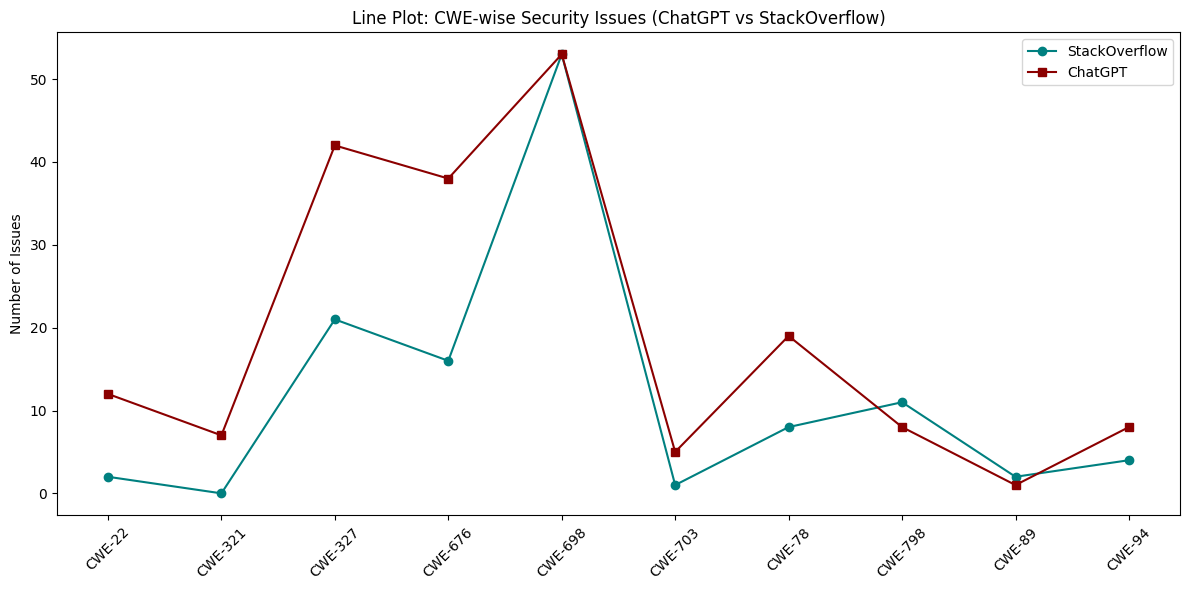

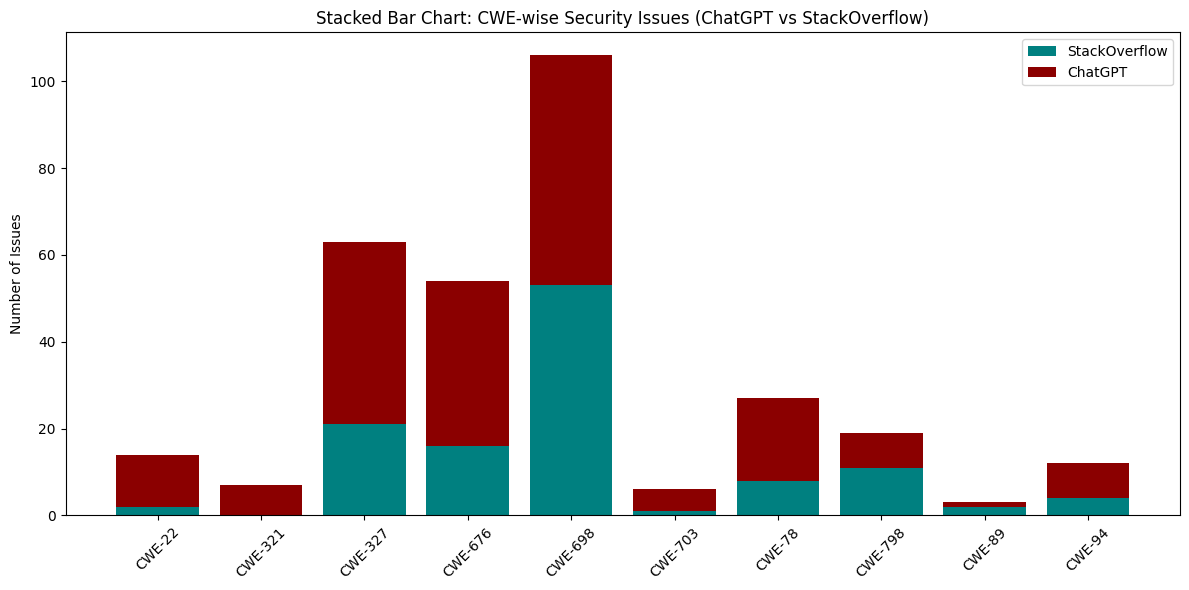

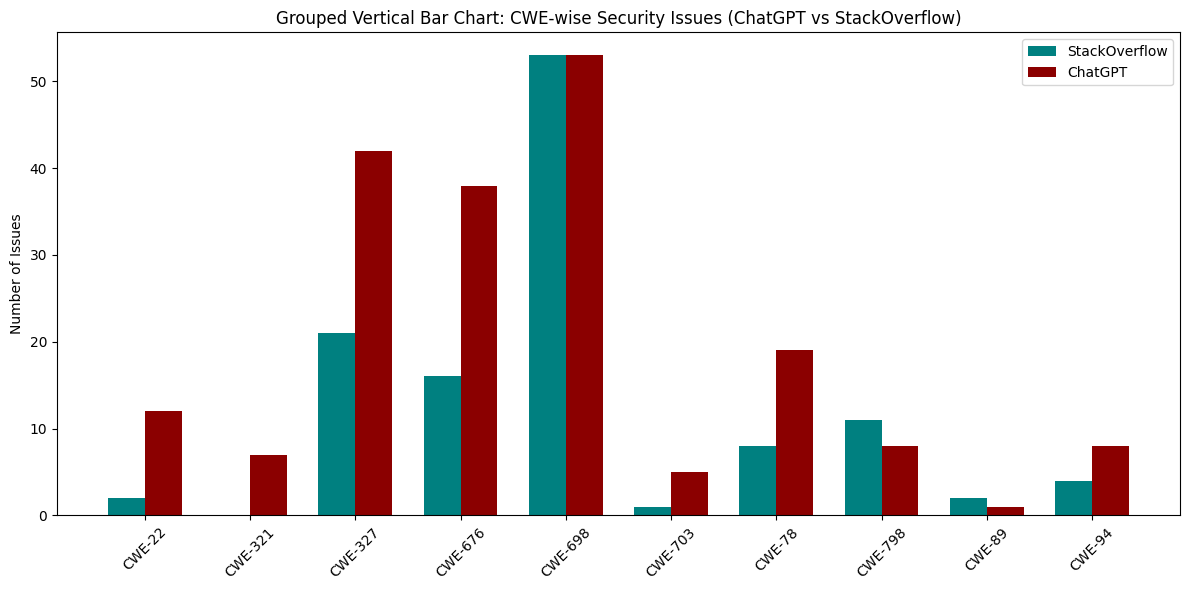

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Step 1: Load CWE summary (or regenerate from earlier steps) ===
cwe_summary = pd.read_csv("bandit_cwe_comparison.csv")

# === Step 2: Setup colors ===
so_color = "#008080"   # teal
gpt_color = "#8B0000"  # dark red

categories = cwe_summary["CWE"]
so_counts = cwe_summary["StackOverflow"]
gpt_counts = cwe_summary["ChatGPT"]

# === Plot 1: Line Plot ===
plt.figure(figsize=(12,6))
plt.plot(categories, so_counts, marker="o", color=so_color, label="StackOverflow")
plt.plot(categories, gpt_counts, marker="s", color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Line Plot: CWE-wise Security Issues (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Stacked Bar Chart ===
plt.figure(figsize=(12,6))
plt.bar(categories, so_counts, color=so_color, label="StackOverflow")
plt.bar(categories, gpt_counts, bottom=so_counts, color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Stacked Bar Chart: CWE-wise Security Issues (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 3: Grouped Vertical Bar Chart ===
plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(categories))

plt.bar(x - bar_width/2, so_counts, width=bar_width, color=so_color, label="StackOverflow")
plt.bar(x + bar_width/2, gpt_counts, width=bar_width, color=gpt_color, label="ChatGPT")

plt.xticks(x, categories, rotation=45)
plt.ylabel("Number of Issues")
plt.title("Grouped Vertical Bar Chart: CWE-wise Security Issues (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()


Running Bandit on StackOverflow code...
Running Bandit on ChatGPT code...

Saved per-snippet results to bandit_snippet_results.csv (2994 rows)

=== Total Issues ===
StackOverflow: 118
ChatGPT: 193

=== Category-wise Issues ===
StackOverflow: {'B311': 13, 'B113': 10, 'B101': 53, 'B323': 1, 'B404': 4, 'B607': 2, 'B603': 3, 'B307': 1, 'B401': 1, 'B604': 1, 'B102': 1, 'B201': 2, 'B301': 3, 'B608': 1, 'B108': 9, 'B110': 2, 'B403': 3, 'B405': 2, 'B314': 2, 'B602': 1, 'B310': 1, 'B615': 1, 'B501': 1}
ChatGPT: {'B311': 25, 'B101': 53, 'B323': 1, 'B404': 8, 'B603': 7, 'B607': 3, 'B401': 1, 'B604': 1, 'B113': 21, 'B403': 4, 'B301': 5, 'B310': 3, 'B602': 1, 'B104': 8, 'B105': 5, 'B201': 1, 'B106': 7, 'B107': 1, 'B102': 5, 'B615': 11, 'B108': 1, 'B307': 3, 'B506': 2, 'B608': 4, 'B405': 1, 'B314': 1, 'B501': 1, 'B605': 1, 'B110': 6, 'B606': 2}

Saved category-wise comparison to bandit_comparison_results.csv


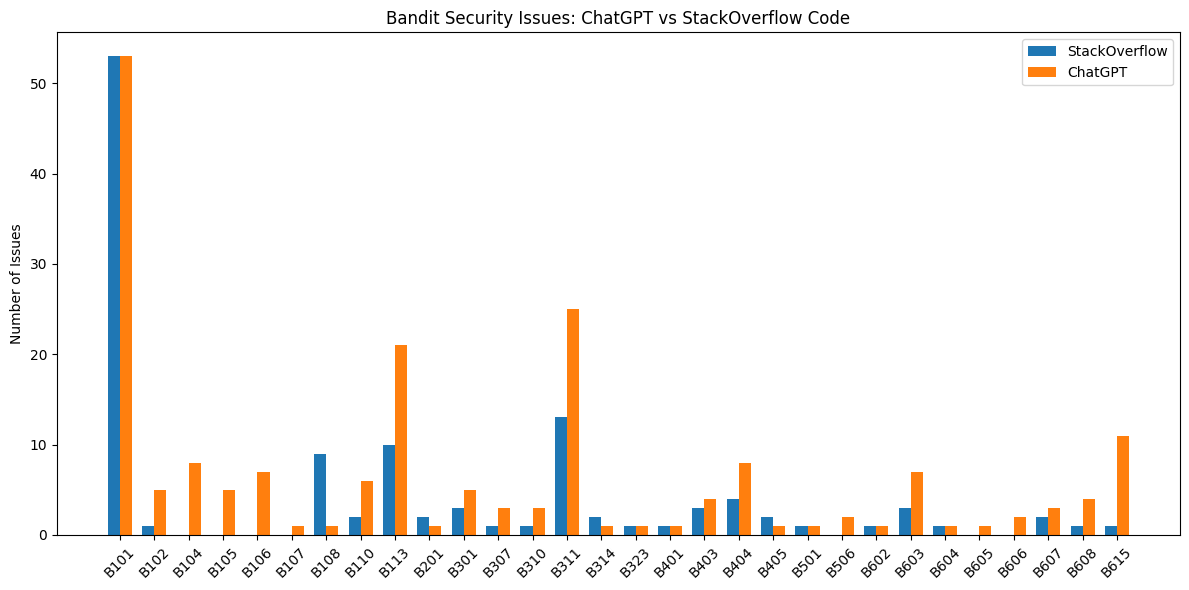

In [ ]:
# 1️⃣ Install Bandit
!pip install bandit

import pandas as pd
import subprocess
import tempfile
import json
import matplotlib.pyplot as plt
from collections import Counter
import sys
import os

# 2️⃣ File paths
so_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_python_SO.csv"
gpt_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_python_CG.csv"

# 3️⃣ Load CSVs
so_df = pd.read_csv(so_file)
gpt_df = pd.read_csv(gpt_file)

def run_bandit_on_code(code_snippet):
    """Run Bandit on a single code snippet and return issue codes found."""
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as tmp_file:
        tmp_file.write(code_snippet if code_snippet else "")
        tmp_path = tmp_file.name

    result = subprocess.run(
        [sys.executable, "-m", "bandit", "-f", "json", "-q", tmp_path],
        capture_output=True,
        text=True
    )

    try:
        output = json.loads(result.stdout)
        issue_codes = [issue["test_id"] for issue in output.get("results", [])]
    except json.JSONDecodeError:
        issue_codes = []

    # Cleanup temp file
    try:
        os.remove(tmp_path)
    except:
        pass

    return issue_codes

def analyze_dataframe(df, source_label, snippet_results):
    """Analyze DataFrame with Bandit, append per-snippet results, and return counts."""
    all_issues = []
    for idx, row in df.iterrows():
        code = row["clean_code"] if not pd.isna(row["clean_code"]) else ""
        issues = run_bandit_on_code(code)
        all_issues.extend(issues)

        snippet_results.append({
            "Snippet_ID": idx,
            "Source": source_label,
            "Code": code,
            "Issues": ", ".join(issues) if issues else ""
        })

    total_issues = len(all_issues)
    category_counts = Counter(all_issues)
    return total_issues, category_counts

# 4️⃣ Analyze both datasets & collect snippet-level results
snippet_results = []

print("Running Bandit on StackOverflow code...")
so_total, so_category_counts = analyze_dataframe(so_df, "StackOverflow", snippet_results)

print("Running Bandit on ChatGPT code...")
gpt_total, gpt_category_counts = analyze_dataframe(gpt_df, "ChatGPT", snippet_results)

# Save snippet-level results
snippets_df = pd.DataFrame(snippet_results)
snippets_df.to_csv("bandit_snippet_results.csv", index=False)
print(f"\nSaved per-snippet results to bandit_snippet_results.csv ({len(snippets_df)} rows)")

# 5️⃣ Print totals
print("\n=== Total Issues ===")
print(f"StackOverflow: {so_total}")
print(f"ChatGPT: {gpt_total}")

print("\n=== Category-wise Issues ===")
print("StackOverflow:", dict(so_category_counts))
print("ChatGPT:", dict(gpt_category_counts))

# 6️⃣ Save category-wise comparison
results_df = pd.DataFrame({
    "Category": sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys())),
    "StackOverflow": [so_category_counts.get(cat, 0) for cat in sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys()))],
    "ChatGPT": [gpt_category_counts.get(cat, 0) for cat in sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys()))]
})
results_df.to_csv("bandit_comparison_results.csv", index=False)
print("\nSaved category-wise comparison to bandit_comparison_results.csv")

# 7️⃣ Plot comparison
categories = results_df["Category"]
so_counts = results_df["StackOverflow"]
gpt_counts = results_df["ChatGPT"]

plt.figure(figsize=(12, 6))
bar_width = 0.35
x = range(len(categories))

plt.bar(x, so_counts, width=bar_width, label="StackOverflow")
plt.bar([i + bar_width for i in x], gpt_counts, width=bar_width, label="ChatGPT")

plt.xticks([i + bar_width / 2 for i in x], categories, rotation=45)
plt.ylabel("Number of Issues")
plt.title("Bandit Security Issues: ChatGPT vs StackOverflow Code")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv("bandit_snippet_results.csv")
chatgpt_failed = df[(df["Source"] == "ChatGPT") & (df["Issues"] != "")]
chatgpt_failed.to_csv("chatgpt_failed_bandit.csv", index=False)
print(f"Saved {len(chatgpt_failed)} ChatGPT failing snippets to chatgpt_failed_bandit.csv")

Saved 1497 ChatGPT failing snippets to chatgpt_failed_bandit.csv


  Using cached pylint-3.3.8-py3-none-any.whl.metadata (12 kB)
  Using cached astroid-3.3.11-py3-none-any.whl.metadata (4.4 kB)
  Using cached isort-6.0.1-py3-none-any.whl.metadata (11 kB)
  Using cached mccabe-0.7.0-py2.py3-none-any.whl.metadata (5.0 kB)
  Using cached tomlkit-0.13.3-py3-none-any.whl.metadata (2.8 kB)
Using cached pylint-3.3.8-py3-none-any.whl (523 kB)
Using cached astroid-3.3.11-py3-none-any.whl (275 kB)
Using cached isort-6.0.1-py3-none-any.whl (94 kB)
Using cached mccabe-0.7.0-py2.py3-none-any.whl (7.3 kB)
Using cached tomlkit-0.13.3-py3-none-any.whl (38 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pylint]2m4/5 [pylint]]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Running pylint on StackOverflow code...
Running pylint on ChatGPT code...

=== Total Issues ===
StackOverflow: 3438
ChatGPT: 4877

=== Category-wise Issues ===
StackOverflow: {'W0301': 10, 'E0401': 329, 'E0602': 1158, 'E1121': 1, 'E

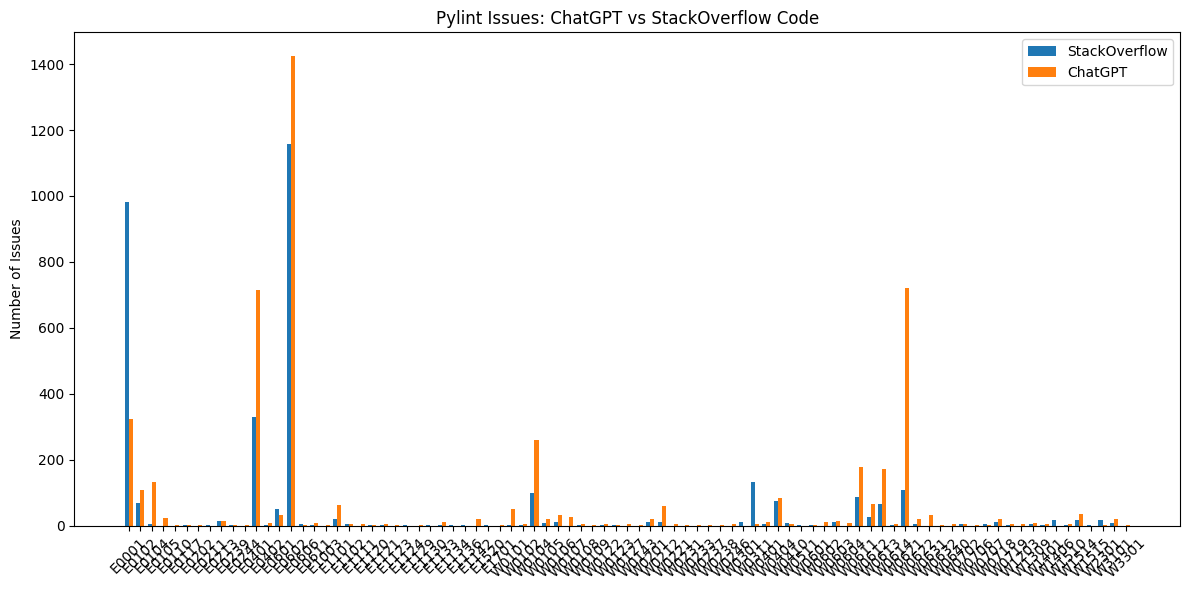

In [ ]:
# 1️⃣ Install pylint
!pip install pylint

import pandas as pd
import subprocess
import tempfile
import json
import matplotlib.pyplot as plt
from collections import Counter
import sys

# 2️⃣ File paths (upload your CSVs to Colab first or mount Google Drive)
so_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_python_SO.csv"
gpt_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_python_CG.csv"

# 3️⃣ Load CSVs
so_df = pd.read_csv(so_file)
gpt_df = pd.read_csv(gpt_file)

def run_pylint_on_code(code_snippet):
    """Run pylint on a single code snippet and return message IDs."""
    # Write code to temp file
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as tmp_file:
        tmp_file.write(code_snippet)
        tmp_path = tmp_file.name

    # Run pylint in JSON mode
    result = subprocess.run(
        [sys.executable, "-m", "pylint", "--output-format=json", "--disable=R,C", tmp_path],
        capture_output=True,
        text=True
    )

    try:
        output = json.loads(result.stdout) if result.stdout.strip() else []
        message_ids = [issue.get("message-id") for issue in output if "message-id" in issue]
    except json.JSONDecodeError:
        message_ids = []

    return message_ids

def analyze_dataframe(df):
    """Analyze all rows of a DataFrame with pylint and return counts."""
    all_issues = []
    for _, row in df.iterrows():
        code = row["clean_code"] if not pd.isna(row["clean_code"]) else ""
        issues = run_pylint_on_code(code)
        all_issues.extend(issues)

    total_issues = len(all_issues)
    category_counts = Counter(all_issues)
    return total_issues, category_counts

# 4️⃣ Analyze both datasets
print("Running pylint on StackOverflow code...")
so_total, so_category_counts = analyze_dataframe(so_df)

print("Running pylint on ChatGPT code...")
gpt_total, gpt_category_counts = analyze_dataframe(gpt_df)

# 5️⃣ Print results
print("\n=== Total Issues ===")
print(f"StackOverflow: {so_total}")
print(f"ChatGPT: {gpt_total}")

print("\n=== Category-wise Issues ===")
print("StackOverflow:", dict(so_category_counts))
print("ChatGPT:", dict(gpt_category_counts))

# 6️⃣ Save results to CSV
results_df = pd.DataFrame({
    "Category": sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys())),
    "StackOverflow": [so_category_counts.get(cat, 0) for cat in sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys()))],
    "ChatGPT": [gpt_category_counts.get(cat, 0) for cat in sorted(set(gpt_category_counts.keys()) | set(so_category_counts.keys()))]
})
results_df.to_csv("pylint_comparison_results.csv", index=False)
print("\nSaved category-wise comparison to pylint_comparison_results.csv")

# 7️⃣ Plot comparison
categories = results_df["Category"]
so_counts = results_df["StackOverflow"]
gpt_counts = results_df["ChatGPT"]

plt.figure(figsize=(12, 6))
bar_width = 0.35
x = range(len(categories))

plt.bar(x, so_counts, width=bar_width, label="StackOverflow")
plt.bar([i + bar_width for i in x], gpt_counts, width=bar_width, label="ChatGPT")

plt.xticks([i + bar_width / 2 for i in x], categories, rotation=45)
plt.ylabel("Number of Issues")
plt.title("Pylint Issues: ChatGPT vs StackOverflow Code")
plt.legend()
plt.tight_layout()
plt.show()


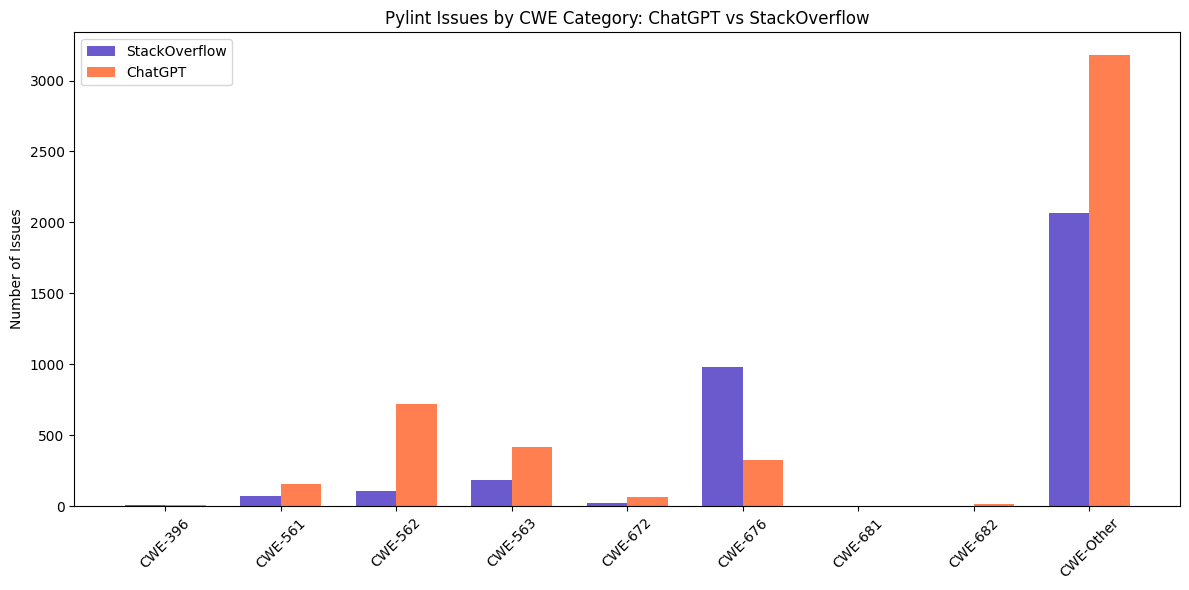

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Load saved results
results_df = pd.read_csv("pylint_comparison_results.csv")

# 2️⃣ Define a simple Pylint → CWE mapping (extend as needed)
pylint_to_cwe = {
    "E0001": "CWE-676",  # Syntax Error → Use of potentially dangerous function
    "E0102": "CWE-561",  # Function redefined
    "E1101": "CWE-672",  # Attribute error (improper handling)
    "E1120": "CWE-682",  # Wrong number of arguments
    "E1121": "CWE-682",
    "E1123": "CWE-682",
    "E1136": "CWE-681",  # Indexing error
    "W0101": "CWE-561",  # Unreachable code
    "W0611": "CWE-563",  # Unused import
    "W0612": "CWE-563",  # Unused variable
    "W0613": "CWE-563",
    "W0621": "CWE-562",  # Variable shadowing
    "W0702": "CWE-396",  # Catching too general exception
    "W0703": "CWE-396",
    "F0001": "CWE-399",  # Fatal error
}

# 3️⃣ Map message IDs to CWE categories
results_df["CWE"] = results_df["Category"].map(pylint_to_cwe).fillna("CWE-Other")

# 4️⃣ Aggregate counts by CWE
cwe_df = results_df.groupby("CWE")[["StackOverflow", "ChatGPT"]].sum().reset_index()

# 5️⃣ Plot comparison (Grouped Bar Chart)
plt.figure(figsize=(12, 6))
bar_width = 0.35
x = range(len(cwe_df))

plt.bar(x, cwe_df["StackOverflow"], width=bar_width, label="StackOverflow", color="#6a5acd")  # SlateBlue
plt.bar([i + bar_width for i in x], cwe_df["ChatGPT"], width=bar_width, label="ChatGPT", color="#ff7f50")  # Coral

plt.xticks([i + bar_width / 2 for i in x], cwe_df["CWE"], rotation=45)
plt.ylabel("Number of Issues")
plt.title("Pylint Issues by CWE Category: ChatGPT vs StackOverflow")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import subprocess
import tempfile
import json
import sys

def run_pylint_on_code(code_snippet):
    """Run pylint on a single code snippet and return detailed issues."""
    with tempfile.NamedTemporaryFile(mode="w", suffix=".py", delete=False) as tmp_file:
        tmp_file.write(code_snippet)
        tmp_path = tmp_file.name

    # Run pylint in JSON mode
    result = subprocess.run(
        [sys.executable, "-m", "pylint", "--output-format=json", "--disable=R,C", tmp_path],
        capture_output=True,
        text=True
    )

    issues = []
    try:
        output = json.loads(result.stdout) if result.stdout.strip() else []
        for issue in output:
            issues.append({
                "error_code": issue.get("message-id", ""),
                "description": issue.get("message", ""),
                "line": issue.get("line", -1)
            })
    except json.JSONDecodeError:
        pass

    return issues


def analyze_dataframe(df, source_label):
    """Analyze all rows of a DataFrame with pylint and return detailed issues."""
    detailed_issues = []
    for idx, row in df.iterrows():
        code = row["clean_code"] if not pd.isna(row["clean_code"]) else ""
        issues = run_pylint_on_code(code)
        for issue in issues:
            # Extract full snippet + error line
            lines = code.splitlines()
            error_line_text = lines[issue["line"] - 1] if 0 < issue["line"] <= len(lines) else ""
            detailed_issues.append({
                "Source": source_label,
                "RowID": idx,
                "ErrorCode": issue["error_code"],
                "Description": issue["description"],
                "ErrorLine": error_line_text.strip(),
                "FullSnippet": code
            })
    return detailed_issues


# Run analysis
print("Running pylint on StackOverflow code...")
so_issues = analyze_dataframe(so_df, "StackOverflow")

print("Running pylint on ChatGPT code...")
gpt_issues = analyze_dataframe(gpt_df, "ChatGPT")

# Combine and save
all_issues_df = pd.DataFrame(so_issues + gpt_issues)
all_issues_df.to_csv("pylint_detailed_results.csv", index=False)

print("\nSaved detailed pylint results to pylint_detailed_results.csv")


Running pylint on StackOverflow code...
Running pylint on ChatGPT code...

Saved detailed pylint results to pylint_detailed_results.csv



Top 10 category results saved to pylint_top10_results.csv
  Category  StackOverflow  ChatGPT
0    E0602           1158     1425
1    E0001            981      322
2    E0401            325      711
3    W0621            109      722
4    W0104            100      259
5    W0611             87      179
6    W0613             67      172
7    E0102             68      107
8    W0404             76       84
9    W0311            133        4


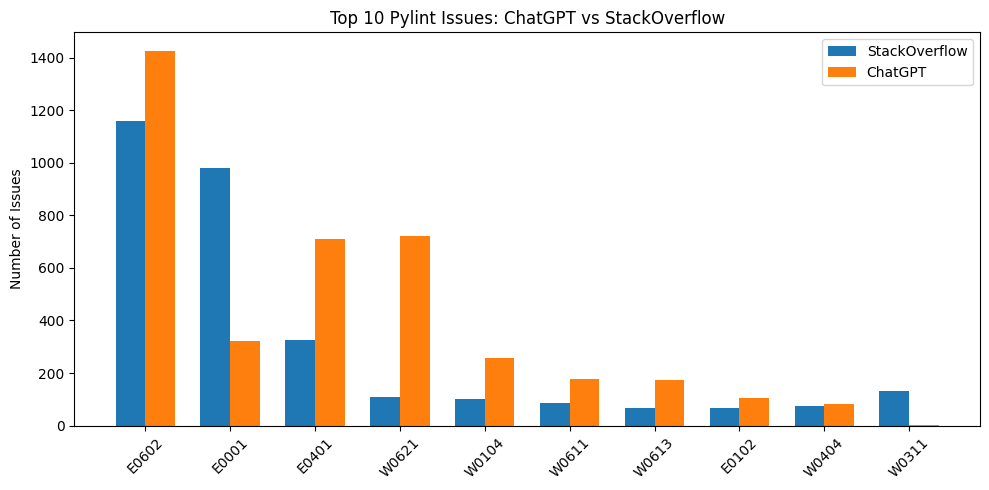


Descriptions for top 10 issues saved to pylint_top10_descriptions.csv
  Message ID Symbol Description
0      E0602   None        None
1      E0001   None        None
2      E0401   None        None
3      W0621   None        None
4      W0104   None        None
5      W0611   None        None
6      W0613   None        None
7      E0102   None        None
8      W0404   None        None
9      W0311   None        None


In [ ]:
# Continuing from previous analysis...

# 🔹 Combine counts and get top 10 by total occurrences
combined_counts = {}
for cat, count in so_category_counts.items():
    combined_counts[cat] = combined_counts.get(cat, 0) + count
for cat, count in gpt_category_counts.items():
    combined_counts[cat] = combined_counts.get(cat, 0) + count

top10_categories = sorted(combined_counts, key=combined_counts.get, reverse=True)[:10]

# Prepare data for top 10
top10_df = pd.DataFrame({
    "Category": top10_categories,
    "StackOverflow": [so_category_counts.get(cat, 0) for cat in top10_categories],
    "ChatGPT": [gpt_category_counts.get(cat, 0) for cat in top10_categories]
})
top10_df.to_csv("pylint_top10_results.csv", index=False)
print("\nTop 10 category results saved to pylint_top10_results.csv")
print(top10_df)

# 🔹 Plot top 10 frequencies
plt.figure(figsize=(10, 5))
bar_width = 0.35
x = range(len(top10_categories))

plt.bar(x, top10_df["StackOverflow"], width=bar_width, label="StackOverflow")
plt.bar([i + bar_width for i in x], top10_df["ChatGPT"], width=bar_width, label="ChatGPT")

plt.xticks([i + bar_width / 2 for i in x], top10_categories, rotation=45)
plt.ylabel("Number of Issues")
plt.title("Top 10 Pylint Issues: ChatGPT vs StackOverflow")
plt.legend()
plt.tight_layout()
plt.show()

# 🔹 Table mapping message IDs to descriptions
# We'll query pylint's messages database for these IDs
from pylint.lint import Run
from pylint.reporters.json_reporter import JSONReporter
from io import StringIO

def get_pylint_message_info(message_id):
    # Run a dummy pylint check to get metadata
    buf = StringIO()
    try:
        Run(["--list-msgs"], reporter=JSONReporter(output=buf), do_exit=False)
        msgs = json.loads(buf.getvalue())
        for msg in msgs:
            if msg["msgid"] == message_id:
                return msg["symbol"], msg["msg"]
    except Exception:
        return None, None
    return None, None

msg_info = []
for cat in top10_categories:
    symbol, description = get_pylint_message_info(cat)
    msg_info.append({"Message ID": cat, "Symbol": symbol, "Description": description})

msg_info_df = pd.DataFrame(msg_info)
msg_info_df.to_csv("pylint_top10_descriptions.csv", index=False)
print("\nDescriptions for top 10 issues saved to pylint_top10_descriptions.csv")
print(msg_info_df)


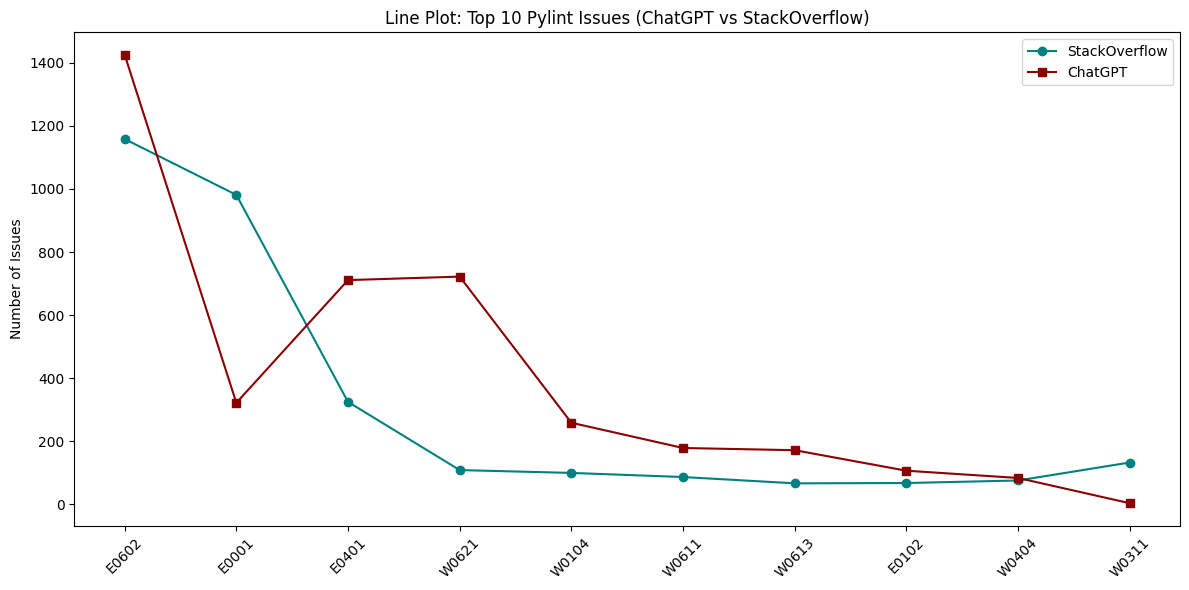

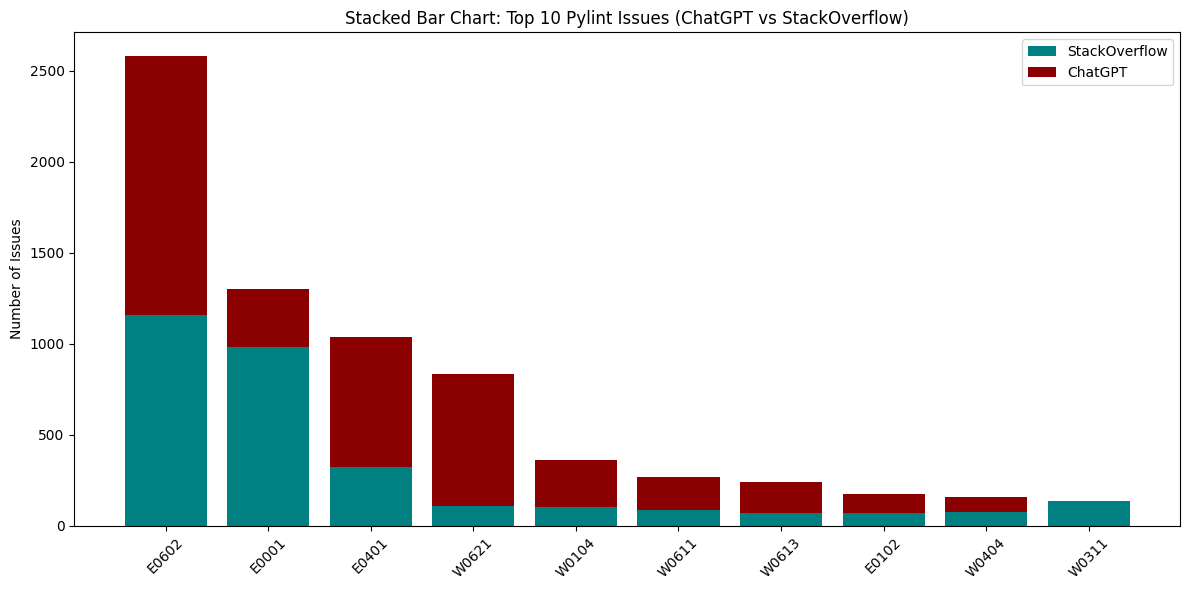

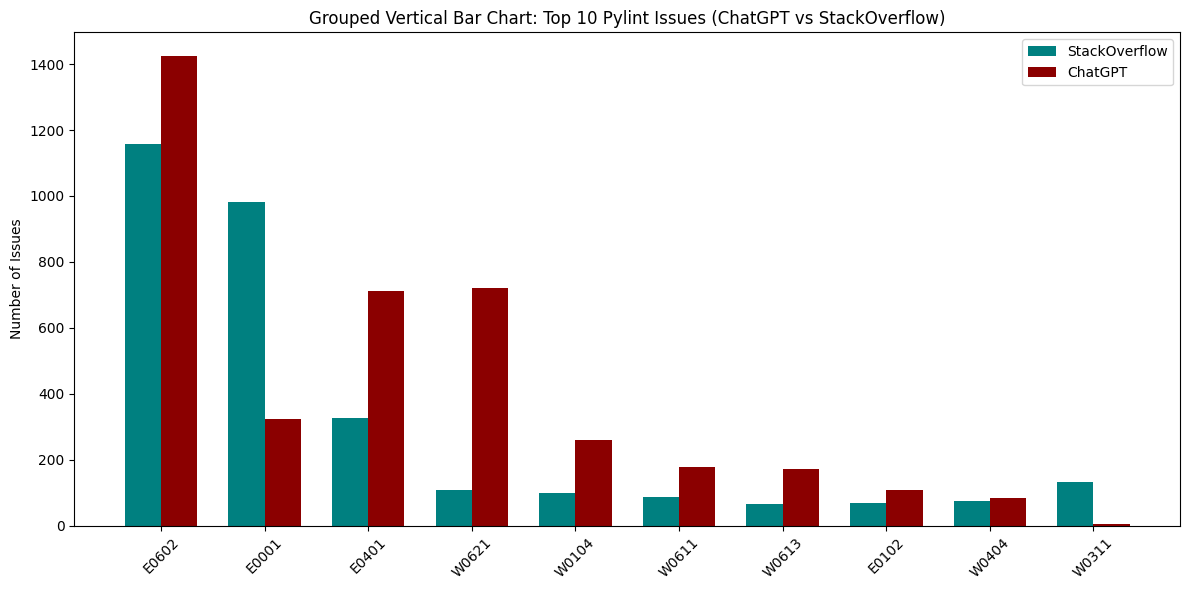

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Step 1: Load saved Top 10 results ===
top10_df = pd.read_csv("pylint_top10_results.csv")

categories = top10_df["Category"]
so_counts = top10_df["StackOverflow"]
gpt_counts = top10_df["ChatGPT"]

# Colors
so_color = "#008080"   # teal
gpt_color = "#8B0000"  # dark red

# === Plot 1: Line Plot ===
plt.figure(figsize=(12,6))
plt.plot(categories, so_counts, marker="o", color=so_color, label="StackOverflow")
plt.plot(categories, gpt_counts, marker="s", color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Line Plot: Top 10 Pylint Issues (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Stacked Bar Chart ===
plt.figure(figsize=(12,6))
plt.bar(categories, so_counts, color=so_color, label="StackOverflow")
plt.bar(categories, gpt_counts, bottom=so_counts, color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45)
plt.ylabel("Number of Issues")
plt.title("Stacked Bar Chart: Top 10 Pylint Issues (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 3: Grouped Vertical Bar Chart ===
plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(categories))

plt.bar(x - bar_width/2, so_counts, width=bar_width, color=so_color, label="StackOverflow")
plt.bar(x + bar_width/2, gpt_counts, width=bar_width, color=gpt_color, label="ChatGPT")

plt.xticks(x, categories, rotation=45)
plt.ylabel("Number of Issues")
plt.title("Grouped Vertical Bar Chart: Top 10 Pylint Issues (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()



Saved top 10 with CWE mapping to pylint_top10_with_cwe.csv
  Category  StackOverflow  ChatGPT  \
0    E0602           1158     1425   
1    E0001            981      322   
2    E0401            325      711   
3    W0621            109      722   
4    W0104            100      259   
5    W0611             87      179   
6    W0613             67      172   
7    E0102             68      107   
8    W0404             76       84   
9    W0311            133        4   

                                                 CWE  
0           CWE-79: Improper Neutralization of Input  
1                             CWE-94: Code Injection  
2  CWE-703: Improper Handling of Exceptional Cond...  
3                           CWE-563: Unused Variable  
4                        CWE-398: Code Quality Issue  
5                                           Unmapped  
6                           CWE-563: Unused Variable  
7                        CWE-398: Code Quality Issue  
8      CWE-670: Improper C

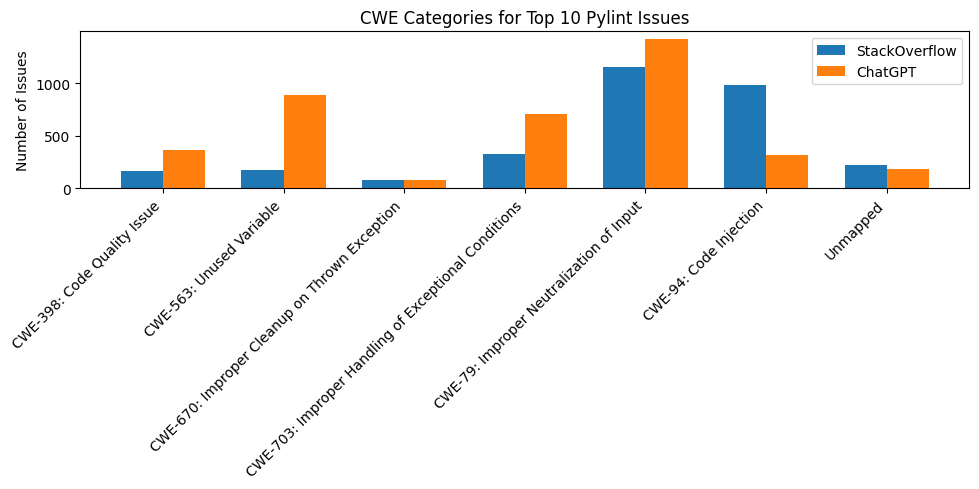

In [ ]:
# Load the top 10 results
top10_df = pd.read_csv("pylint_top10_results.csv")

# Manual CWE mapping for common pylint IDs
pylint_to_cwe = {
    "E0602": "CWE-79: Improper Neutralization of Input",  # Undefined variable - could be injection in some cases
    "E0401": "CWE-703: Improper Handling of Exceptional Conditions",  # Import error
    "E0001": "CWE-94: Code Injection",  # SyntaxError
    "W0621": "CWE-563: Unused Variable",
    "W0612": "CWE-563: Unused Variable",
    "W0104": "CWE-398: Code Quality Issue",
    "W0613": "CWE-563: Unused Variable",
    "E1101": "CWE-476: Null Pointer Dereference",  # Attribute not found
    "W0404": "CWE-670: Improper Cleanup on Thrown Exception",
    "E0102": "CWE-398: Code Quality Issue",
    # add more mappings as needed for your dataset...
}

# Map to CWE
top10_df["CWE"] = top10_df["Category"].map(lambda x: pylint_to_cwe.get(x, "Unmapped"))

# Aggregate by CWE
cwe_grouped = top10_df.groupby("CWE").sum(numeric_only=True).reset_index()

# Save mapping table
top10_df.to_csv("pylint_top10_with_cwe.csv", index=False)
print("\nSaved top 10 with CWE mapping to pylint_top10_with_cwe.csv")
print(top10_df)

# Plot CWE frequencies
plt.figure(figsize=(10, 5))
bar_width = 0.35
x = range(len(cwe_grouped))

plt.bar(x, cwe_grouped["StackOverflow"], width=bar_width, label="StackOverflow")
plt.bar([i + bar_width for i in x], cwe_grouped["ChatGPT"], width=bar_width, label="ChatGPT")

plt.xticks([i + bar_width / 2 for i in x], cwe_grouped["CWE"], rotation=45, ha="right")
plt.ylabel("Number of Issues")
plt.title("CWE Categories for Top 10 Pylint Issues")
plt.legend()
plt.tight_layout()
plt.show()


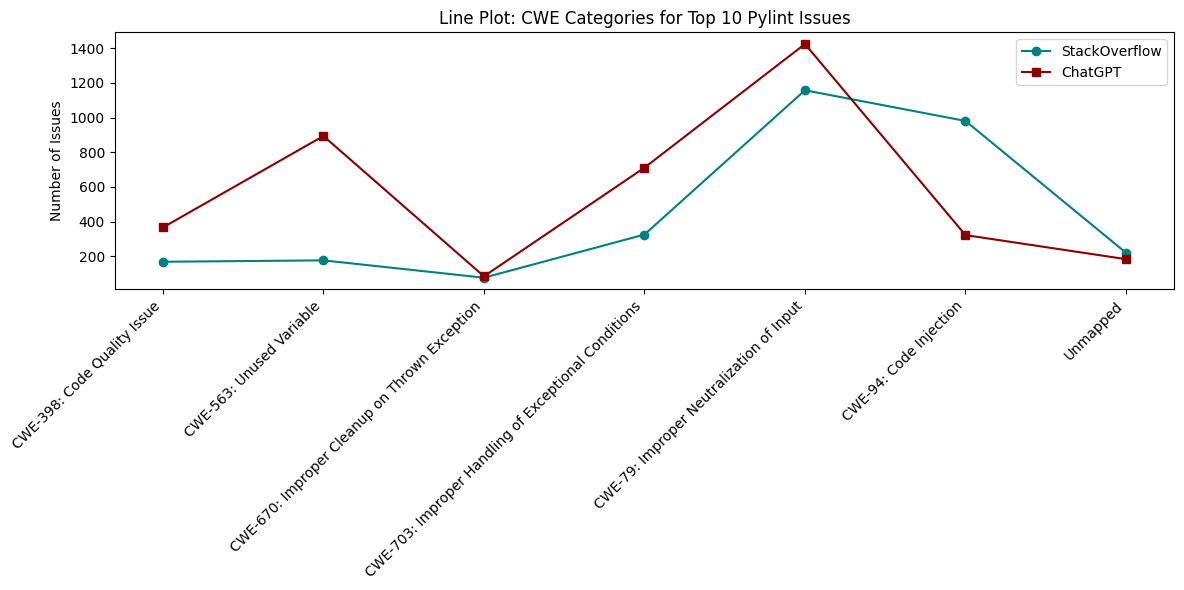

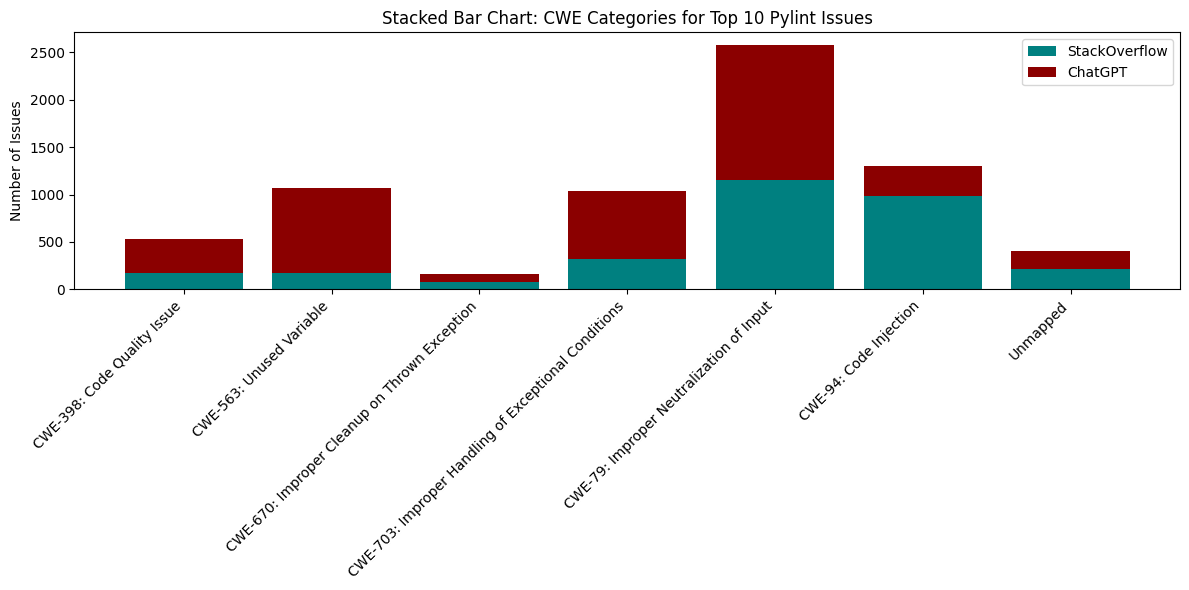

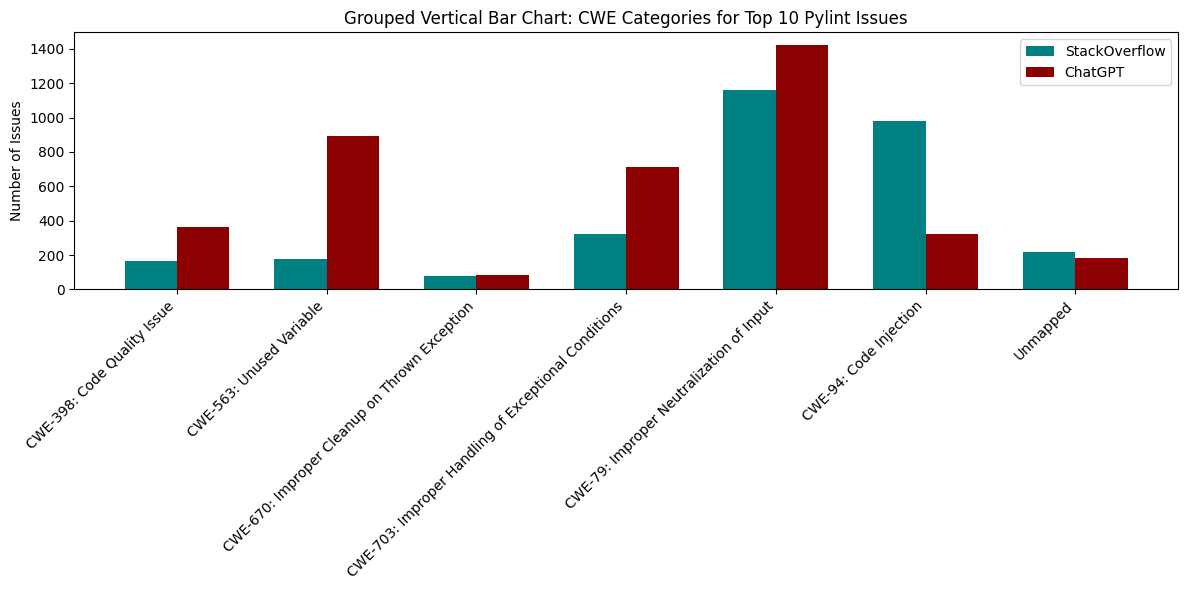

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Step 1: Load CWE-mapped Top 10 results ===
top10_df = pd.read_csv("pylint_top10_with_cwe.csv")

# Aggregate by CWE
cwe_grouped = top10_df.groupby("CWE")[["StackOverflow", "ChatGPT"]].sum().reset_index()

categories = cwe_grouped["CWE"]
so_counts = cwe_grouped["StackOverflow"]
gpt_counts = cwe_grouped["ChatGPT"]

# Colors
so_color = "#008080"   # teal
gpt_color = "#8B0000"  # dark red

# === Plot 1: Line Plot ===
plt.figure(figsize=(12,6))
plt.plot(categories, so_counts, marker="o", color=so_color, label="StackOverflow")
plt.plot(categories, gpt_counts, marker="s", color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Issues")
plt.title("Line Plot: CWE Categories for Top 10 Pylint Issues")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Stacked Bar Chart ===
plt.figure(figsize=(12,6))
plt.bar(categories, so_counts, color=so_color, label="StackOverflow")
plt.bar(categories, gpt_counts, bottom=so_counts, color=gpt_color, label="ChatGPT")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Issues")
plt.title("Stacked Bar Chart: CWE Categories for Top 10 Pylint Issues")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 3: Grouped Vertical Bar Chart ===
plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(categories))

plt.bar(x - bar_width/2, so_counts, width=bar_width, color=so_color, label="StackOverflow")
plt.bar(x + bar_width/2, gpt_counts, width=bar_width, color=gpt_color, label="ChatGPT")

plt.xticks(x, categories, rotation=45, ha="right")
plt.ylabel("Number of Issues")
plt.title("Grouped Vertical Bar Chart: CWE Categories for Top 10 Pylint Issues")
plt.legend()
plt.tight_layout()
plt.show()


Using PMD at: pmd-bin-7.7.0/bin/pmd
Running PMD on StackOverflow Java code...
Running PMD on ChatGPT Java code...

=== Total Issues ===
StackOverflow: 273
ChatGPT: 202

=== Category-wise Issues ===
StackOverflow: {'AvoidFieldNameMatchingMethodName': 10, 'AvoidFieldNameMatchingTypeName': 3, 'CloseResource': 57, 'NullAssignment': 2, 'TestClassWithoutTestCases': 51, 'MissingSerialVersionUID': 23, 'DoNotTerminateVM': 4, 'AvoidLiteralsInIfCondition': 32, 'ConstructorCallsOverridableMethod': 39, 'CompareObjectsWithEquals': 2, 'AvoidDuplicateLiterals': 13, 'DoNotCallGarbageCollectionExplicitly': 1, 'AssignmentInOperand': 5, 'AvoidAccessibilityAlteration': 1, 'UnnecessaryCaseChange': 2, 'UseLocaleWithCaseConversions': 6, 'DoNotThrowExceptionInFinally': 1, 'NonSerializableClass': 6, 'ReturnEmptyCollectionRatherThanNull': 1, 'AvoidBranchingStatementAsLastInLoop': 1, 'AvoidCatchingThrowable': 7, 'EmptyCatchBlock': 1, 'MethodWithSameNameAsEnclosingClass': 1, 'NonStaticInitializer': 1, 'MissingStat

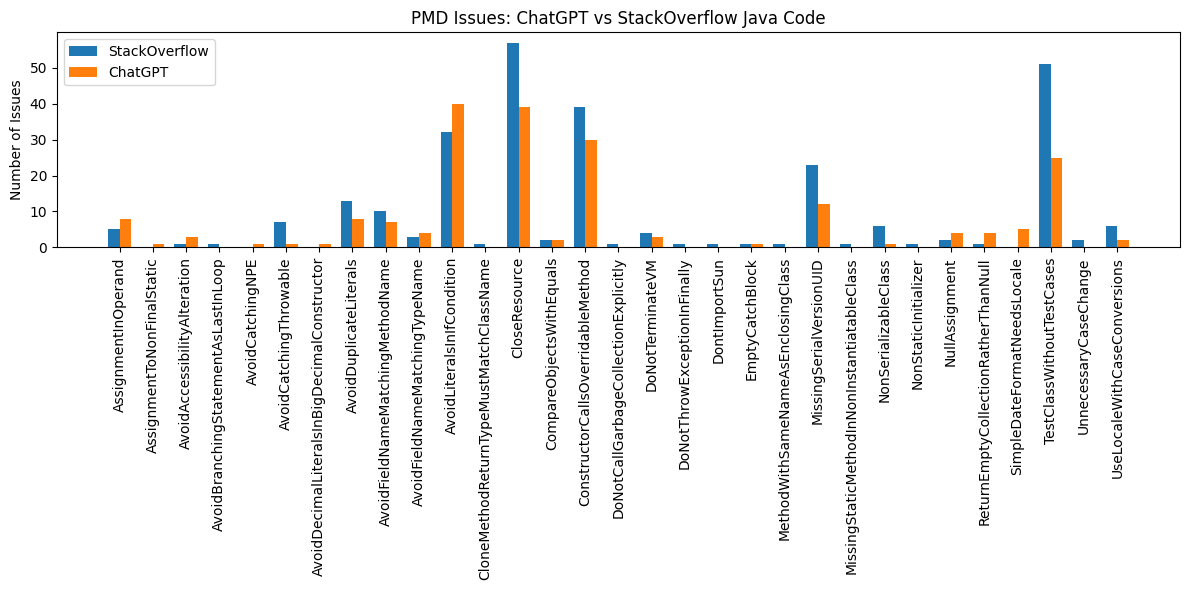

In [ ]:
import os
import platform
import pandas as pd
import subprocess
import tempfile
import json
import matplotlib.pyplot as plt
from collections import Counter
import urllib.request
import zipfile

# PMD version
PMD_VERSION = "7.7.0"
PMD_FOLDER = f"pmd-bin-{PMD_VERSION}"
PMD_ZIP = f"{PMD_FOLDER}-bin.zip"
PMD_URL = f"https://github.com/pmd/pmd/releases/download/pmd_releases%2F{PMD_VERSION.replace('.', '%2F')}/{PMD_ZIP}"

# 1️⃣ Download PMD if missing
if not os.path.exists(PMD_FOLDER):
    print(f"Downloading PMD {PMD_VERSION}...")
    urllib.request.urlretrieve(PMD_URL, PMD_ZIP)
    with zipfile.ZipFile(PMD_ZIP, "r") as zip_ref:
        zip_ref.extractall(".")
    os.remove(PMD_ZIP)
    print("PMD downloaded and extracted.")

# 2️⃣ Detect OS and set PMD executable
if platform.system() == "Windows":
    PMD_PATH = os.path.join(PMD_FOLDER, "bin", "pmd.bat")
else:
    PMD_PATH = os.path.join(PMD_FOLDER, "bin", "pmd")

if not os.path.isfile(PMD_PATH):
    raise FileNotFoundError(f"PMD executable not found at: {PMD_PATH}")

print(f"Using PMD at: {PMD_PATH}")

# 3️⃣ CSV file paths (update these to your actual file paths)
so_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_java_SO.csv"
gpt_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_java_CG.csv"

# Load data
so_df = pd.read_csv(so_file)
gpt_df = pd.read_csv(gpt_file)

def run_pmd_on_code(code_snippet):
    """Run PMD on a single Java code snippet and return rule names found."""
    temp_dir = tempfile.mkdtemp()
    java_file_path = os.path.join(temp_dir, "Temp.java")

    with open(java_file_path, "w") as f:
        f.write(code_snippet)

    result = subprocess.run(
        [
            PMD_PATH,
            "check",
            "-d", java_file_path,
            "-R", "category/java/errorprone.xml",
            "-f", "json"
        ],
        capture_output=True,
        text=True
    )

    try:
        output = json.loads(result.stdout) if result.stdout.strip() else {}
        issues = []
        for file_report in output.get("files", []):
            for violation in file_report.get("violations", []):
                issues.append(violation.get("rule", "UnknownRule"))
    except json.JSONDecodeError:
        issues = []

    return issues

def analyze_dataframe(df):
    """Analyze all rows of a DataFrame with PMD and return counts."""
    all_issues = []
    for _, row in df.iterrows():
        code = row["clean_code"] if not pd.isna(row["clean_code"]) else ""
        issues = run_pmd_on_code(code)
        all_issues.extend(issues)

    total_issues = len(all_issues)
    category_counts = Counter(all_issues)
    return total_issues, category_counts

# 4️⃣ Run analysis
print("Running PMD on StackOverflow Java code...")
so_total, so_category_counts = analyze_dataframe(so_df)

print("Running PMD on ChatGPT Java code...")
gpt_total, gpt_category_counts = analyze_dataframe(gpt_df)

# 5️⃣ Results
print("\n=== Total Issues ===")
print(f"StackOverflow: {so_total}")
print(f"ChatGPT: {gpt_total}")

print("\n=== Category-wise Issues ===")
print("StackOverflow:", dict(so_category_counts))
print("ChatGPT:", dict(gpt_category_counts))

# 6️⃣ Save results
results_df = pd.DataFrame({
    "Category": sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys())),
    "StackOverflow": [so_category_counts.get(cat, 0) for cat in sorted(set(so_category_counts.keys()) | set(gpt_category_counts.keys()))],
    "ChatGPT": [gpt_category_counts.get(cat, 0) for cat in sorted(set(gpt_category_counts.keys()) | set(so_category_counts.keys()))]
})
results_df.to_csv("pmd_comparison_results.csv", index=False)
print("\nSaved category-wise comparison to pmd_comparison_results.csv")

# 7️⃣ Plot
categories = results_df["Category"]
so_counts = results_df["StackOverflow"]
gpt_counts = results_df["ChatGPT"]

plt.figure(figsize=(12, 6))
bar_width = 0.35
x = range(len(categories))

plt.bar(x, so_counts, width=bar_width, label="StackOverflow")
plt.bar([i + bar_width for i in x], gpt_counts, width=bar_width, label="ChatGPT")

plt.xticks([i + bar_width / 2 for i in x], categories, rotation=90)
plt.ylabel("Number of Issues")
plt.title("PMD Issues: ChatGPT vs StackOverflow Java Code")
plt.legend()
plt.tight_layout()
plt.show()


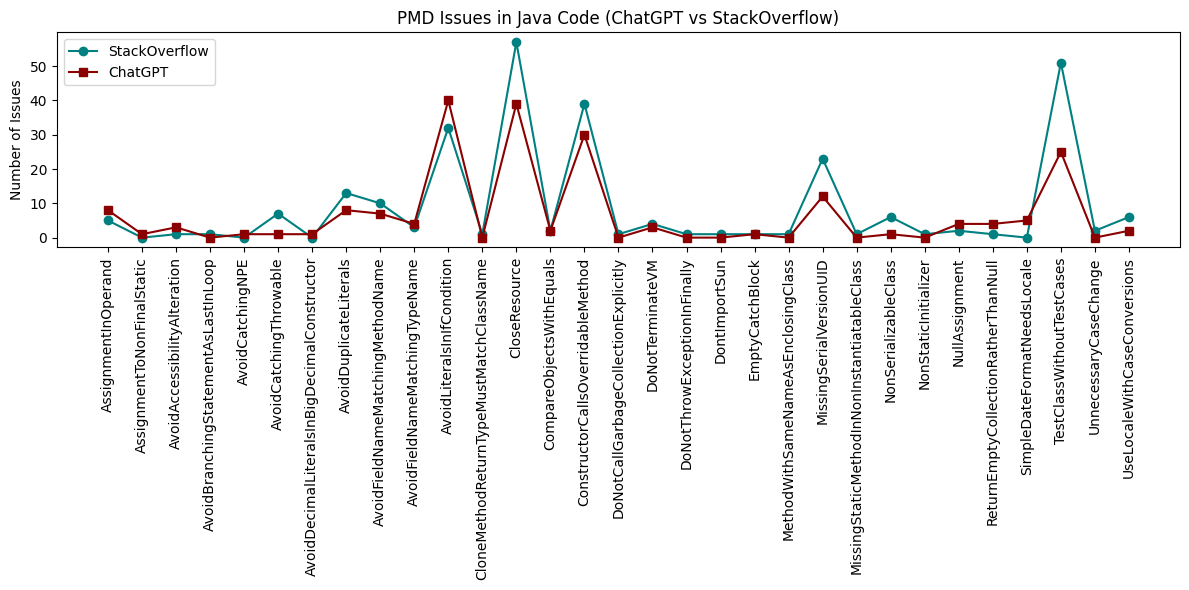

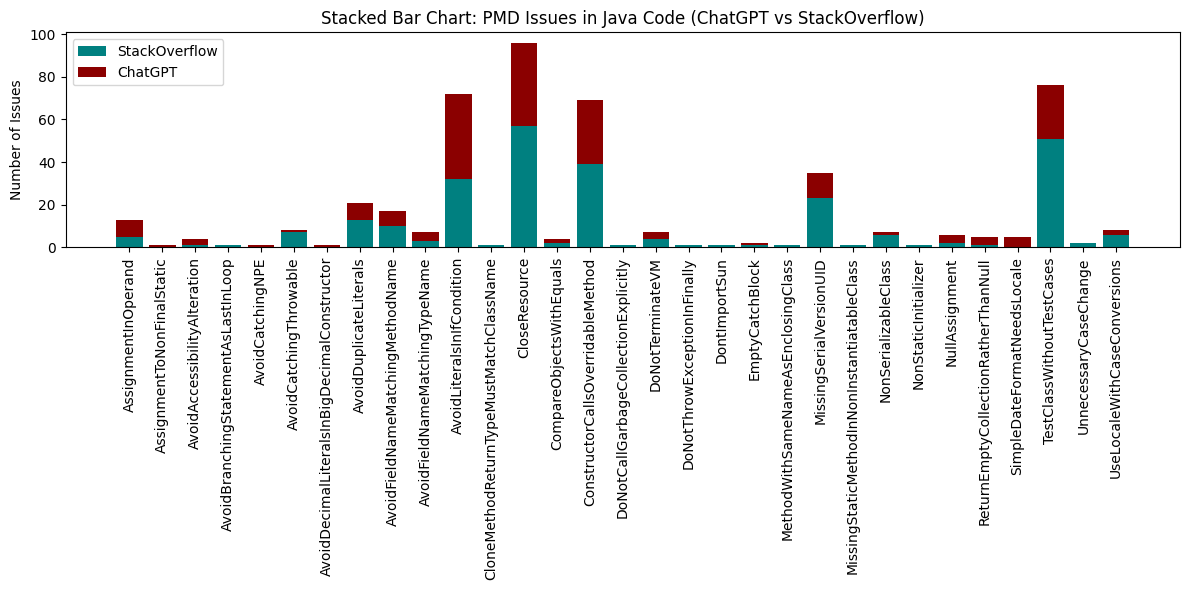

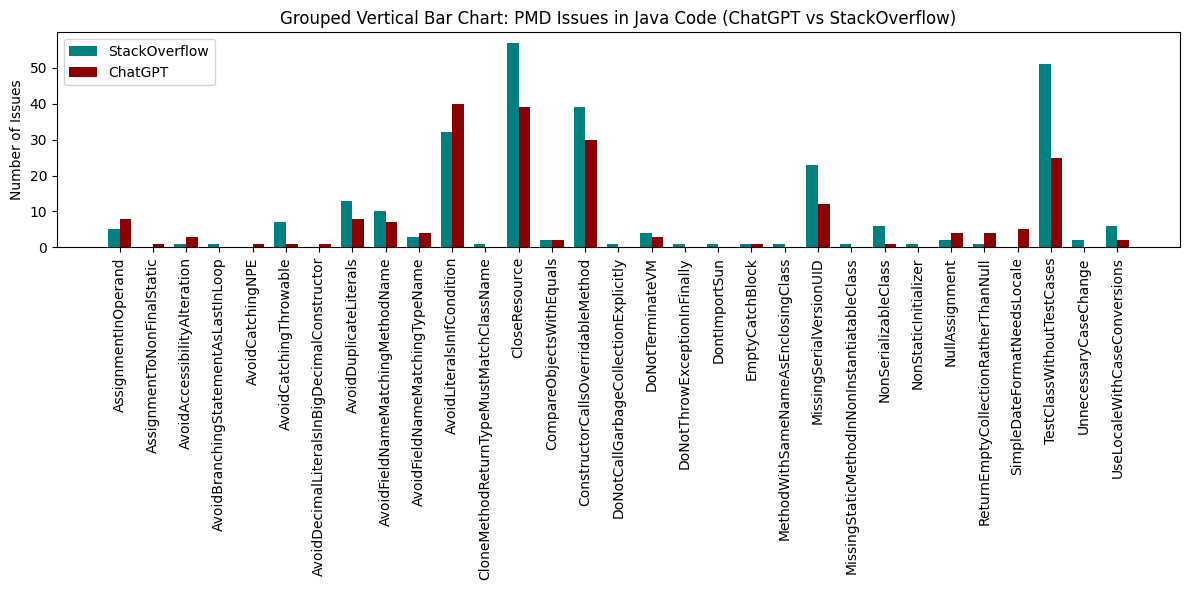

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Load results from CSV (already saved earlier) ===
results_df = pd.read_csv("pmd_comparison_results.csv")

categories = results_df["Category"]
so_counts = results_df["StackOverflow"]
gpt_counts = results_df["ChatGPT"]

# Colors
so_color = "#008080"   # teal
gpt_color = "#8B0000"  # dark red

# === Plot 1: Line Plot ===
plt.figure(figsize=(12,6))
plt.plot(categories, so_counts, marker="o", color=so_color, label="StackOverflow")
plt.plot(categories, gpt_counts, marker="s", color=gpt_color, label="ChatGPT")
plt.xticks(rotation=90)
plt.ylabel("Number of Issues")
plt.title("PMD Issues in Java Code (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Stacked Bar Chart ===
plt.figure(figsize=(12,6))
plt.bar(categories, so_counts, color=so_color, label="StackOverflow")
plt.bar(categories, gpt_counts, bottom=so_counts, color=gpt_color, label="ChatGPT")
plt.xticks(rotation=90)
plt.ylabel("Number of Issues")
plt.title("Stacked Bar Chart: PMD Issues in Java Code (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 3: Grouped Vertical Bar Chart ===
plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(categories))

plt.bar(x - bar_width/2, so_counts, width=bar_width, color=so_color, label="StackOverflow")
plt.bar(x + bar_width/2, gpt_counts, width=bar_width, color=gpt_color, label="ChatGPT")

plt.xticks(x, categories, rotation=90)
plt.ylabel("Number of Issues")
plt.title("Grouped Vertical Bar Chart: PMD Issues in Java Code (ChatGPT vs StackOverflow)")
plt.legend()
plt.tight_layout()
plt.show()


Using PMD at: pmd-bin-7.7.0/bin/pmd
Running PMD on StackOverflow Java code...
Running PMD on ChatGPT Java code...

Detailed results saved to pmd_detailed_results.csv

Summary saved to pmd_summary_results.csv


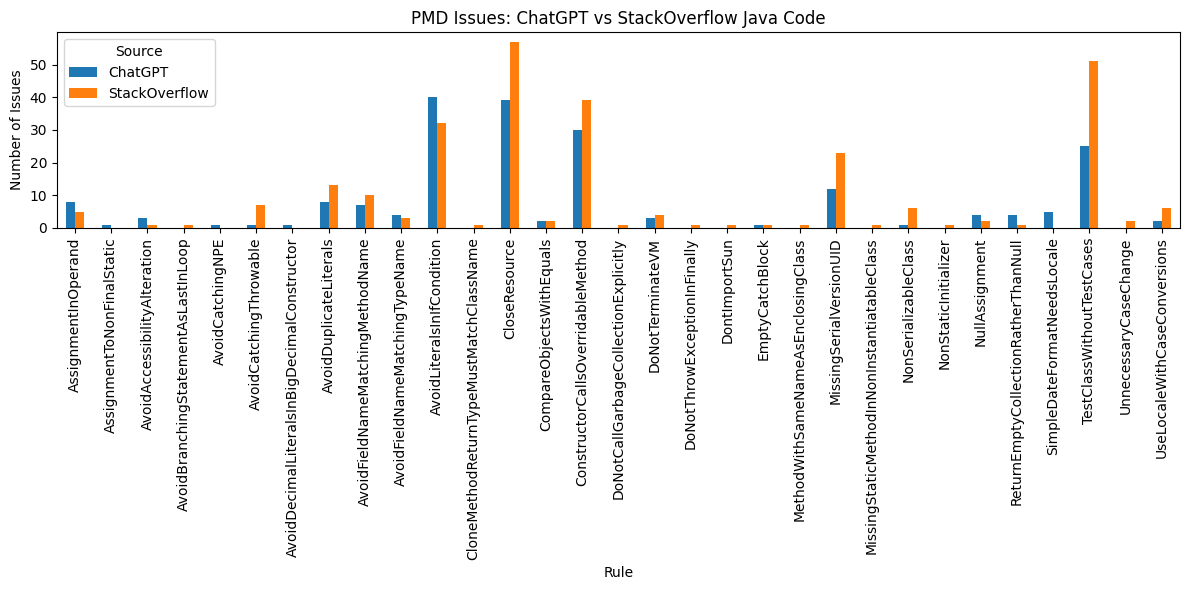

In [ ]:
import os
import platform
import pandas as pd
import subprocess
import tempfile
import json
import matplotlib.pyplot as plt
from collections import Counter
import urllib.request
import zipfile

# PMD version
PMD_VERSION = "7.7.0"
PMD_FOLDER = f"pmd-bin-{PMD_VERSION}"
PMD_ZIP = f"{PMD_FOLDER}-bin.zip"
PMD_URL = f"https://github.com/pmd/pmd/releases/download/pmd_releases%2F{PMD_VERSION.replace('.', '%2F')}/{PMD_ZIP}"

# 1️⃣ Download PMD if missing
if not os.path.exists(PMD_FOLDER):
    print(f"Downloading PMD {PMD_VERSION}...")
    urllib.request.urlretrieve(PMD_URL, PMD_ZIP)
    with zipfile.ZipFile(PMD_ZIP, "r") as zip_ref:
        zip_ref.extractall(".")
    os.remove(PMD_ZIP)
    print("PMD downloaded and extracted.")

# 2️⃣ Detect OS and set PMD executable
if platform.system() == "Windows":
    PMD_PATH = os.path.join(PMD_FOLDER, "bin", "pmd.bat")
else:
    PMD_PATH = os.path.join(PMD_FOLDER, "bin", "pmd")

if not os.path.isfile(PMD_PATH):
    raise FileNotFoundError(f"PMD executable not found at: {PMD_PATH}")

print(f"Using PMD at: {PMD_PATH}")

# 3️⃣ CSV file paths
so_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_java_SO.csv"
gpt_file = "/home/aman/Home/AMAN/Plag/Chatgpt_Vs_SO/combined_java_CG.csv"

# Load data
so_df = pd.read_csv(so_file)
gpt_df = pd.read_csv(gpt_file)

def run_pmd_on_code(code_snippet):
    """Run PMD on a single Java code snippet and return detailed issues."""
    temp_dir = tempfile.mkdtemp()
    java_file_path = os.path.join(temp_dir, "Temp.java")

    with open(java_file_path, "w") as f:
        f.write(code_snippet)

    result = subprocess.run(
        [
            PMD_PATH,
            "check",
            "-d", java_file_path,
            "-R", "category/java/errorprone.xml",
            "-f", "json"
        ],
        capture_output=True,
        text=True
    )

    issues = []
    try:
        output = json.loads(result.stdout) if result.stdout.strip() else {}
        for file_report in output.get("files", []):
            for violation in file_report.get("violations", []):
                rule = violation.get("rule", "UnknownRule")
                desc = violation.get("description", "")
                begin = violation.get("beginline", -1)
                end = violation.get("endline", -1)

                # full snippet
                full_snippet = code_snippet

                # specific lines
                snippet_lines = code_snippet.split("\n")
                if begin > 0 and end > 0 and begin <= len(snippet_lines):
                    specific = "\n".join(snippet_lines[begin-1:end])
                else:
                    specific = ""

                issues.append({
                    "Rule": rule,
                    "Description": desc,
                    "FullSnippet": full_snippet,
                    "ErrorLines": specific
                })
    except json.JSONDecodeError:
        pass

    return issues

def analyze_dataframe(df, source_name):
    """Analyze all rows of a DataFrame with PMD and return detailed results."""
    rows = []
    for _, row in df.iterrows():
        code = row["clean_code"] if not pd.isna(row["clean_code"]) else ""
        issues = run_pmd_on_code(code)
        for issue in issues:
            issue["Source"] = source_name
            rows.append(issue)
    return pd.DataFrame(rows)

# 4️⃣ Run analysis
print("Running PMD on StackOverflow Java code...")
so_results = analyze_dataframe(so_df, "StackOverflow")

print("Running PMD on ChatGPT Java code...")
gpt_results = analyze_dataframe(gpt_df, "ChatGPT")

# Combine results
results_df = pd.concat([so_results, gpt_results], ignore_index=True)

# 5️⃣ Save detailed results
results_df.to_csv("pmd_detailed_results.csv", index=False)
print("\nDetailed results saved to pmd_detailed_results.csv")

# 6️⃣ Summary table (counts per rule per source)
summary = results_df.groupby(["Rule", "Source"]).size().unstack(fill_value=0)
summary.to_csv("pmd_summary_results.csv")
print("\nSummary saved to pmd_summary_results.csv")

# 7️⃣ Plot
summary.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Number of Issues")
plt.title("PMD Issues: ChatGPT vs StackOverflow Java Code")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


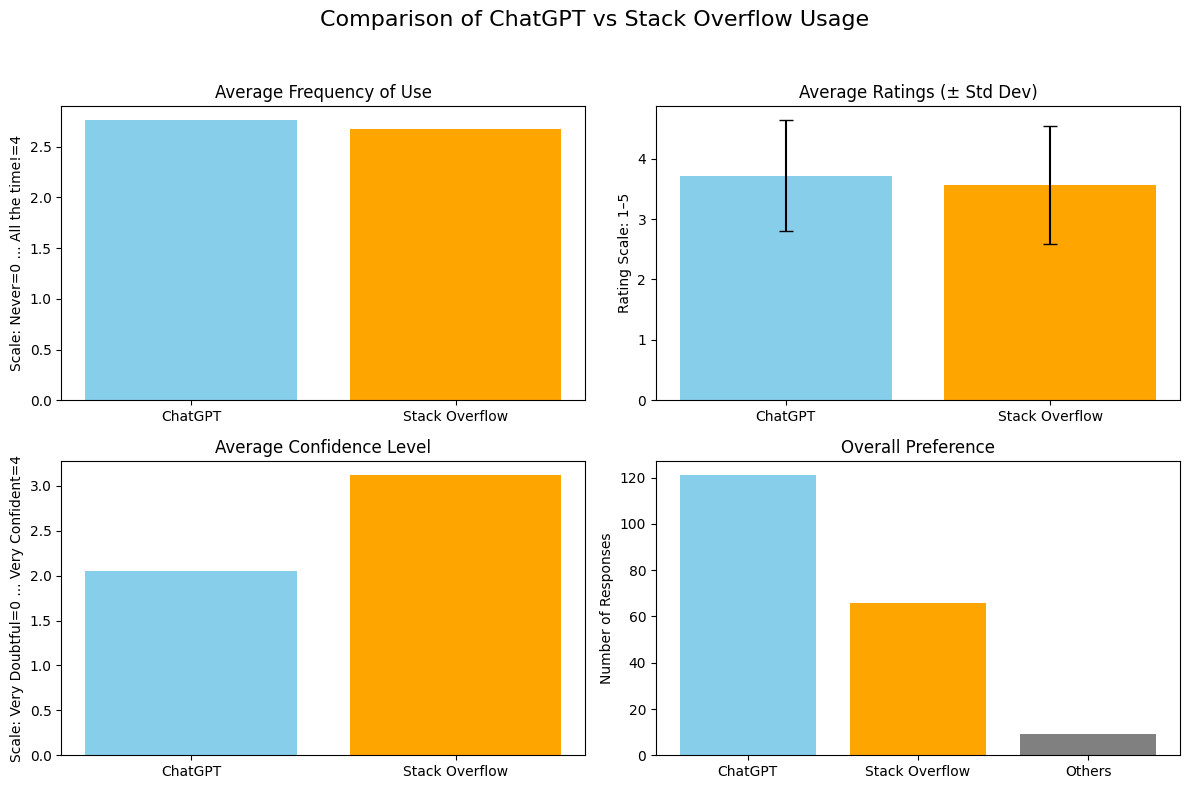

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("Reviews.csv")

# Define mapping for frequency and confidence levels
freq_map = {
    "Never": 0, "Rarely": 1, "Occasionally": 2,
    "Frequently": 3, "All the time!": 4
}
conf_map = {
    "Very Doubtful": 0, "Somewhat Doubtful": 1, "Neutral": 2,
    "Somewhat Confident": 3, "Very Confident": 4
}

# Map values to numeric
df["FCG_num"] = df["FCG"].map(freq_map)
df["FSO_num"] = df["FSO"].map(freq_map)
df["CCG_num"] = df["CCG"].map(conf_map)
df["CSO_num"] = df["CSO"].map(conf_map)

# Normalize preference categories
df["PREFERENCE_CLEAN"] = df["PREFERENCE"].apply(
    lambda x: x if x in ["ChatGPT", "Stack Overflow"] else "Others"
)

# Set up figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Comparison of ChatGPT vs Stack Overflow Usage", fontsize=16)

# --- 1. Frequency of Use ---
axes[0, 0].bar(["ChatGPT", "Stack Overflow"],
               [df["FCG_num"].mean(), df["FSO_num"].mean()],
               color=["skyblue", "orange"])
axes[0, 0].set_title("Average Frequency of Use")
axes[0, 0].set_ylabel("Scale: Never=0 ... All the time!=4")

# --- 2. Ratings (Bar chart with error bars) ---
ratings_means = [df["RCG"].mean(), df["RSO"].mean()]
ratings_std = [df["RCG"].std(), df["RSO"].std()]
axes[0, 1].bar(["ChatGPT", "Stack Overflow"],
               ratings_means, yerr=ratings_std,
               capsize=5, color=["skyblue", "orange"])
axes[0, 1].set_title("Average Ratings (± Std Dev)")
axes[0, 1].set_ylabel("Rating Scale: 1–5")

# --- 3. Confidence Levels ---
axes[1, 0].bar(["ChatGPT", "Stack Overflow"],
               [df["CCG_num"].mean(), df["CSO_num"].mean()],
               color=["skyblue", "orange"])
axes[1, 0].set_title("Average Confidence Level")
axes[1, 0].set_ylabel("Scale: Very Doubtful=0 ... Very Confident=4")

# --- 4. Preference (Grouped) ---
pref_counts = df["PREFERENCE_CLEAN"].value_counts()
axes[1, 1].bar(pref_counts.index, pref_counts.values,
               color=["skyblue", "orange", "gray"])
axes[1, 1].set_title("Overall Preference")
axes[1, 1].set_ylabel("Number of Responses")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


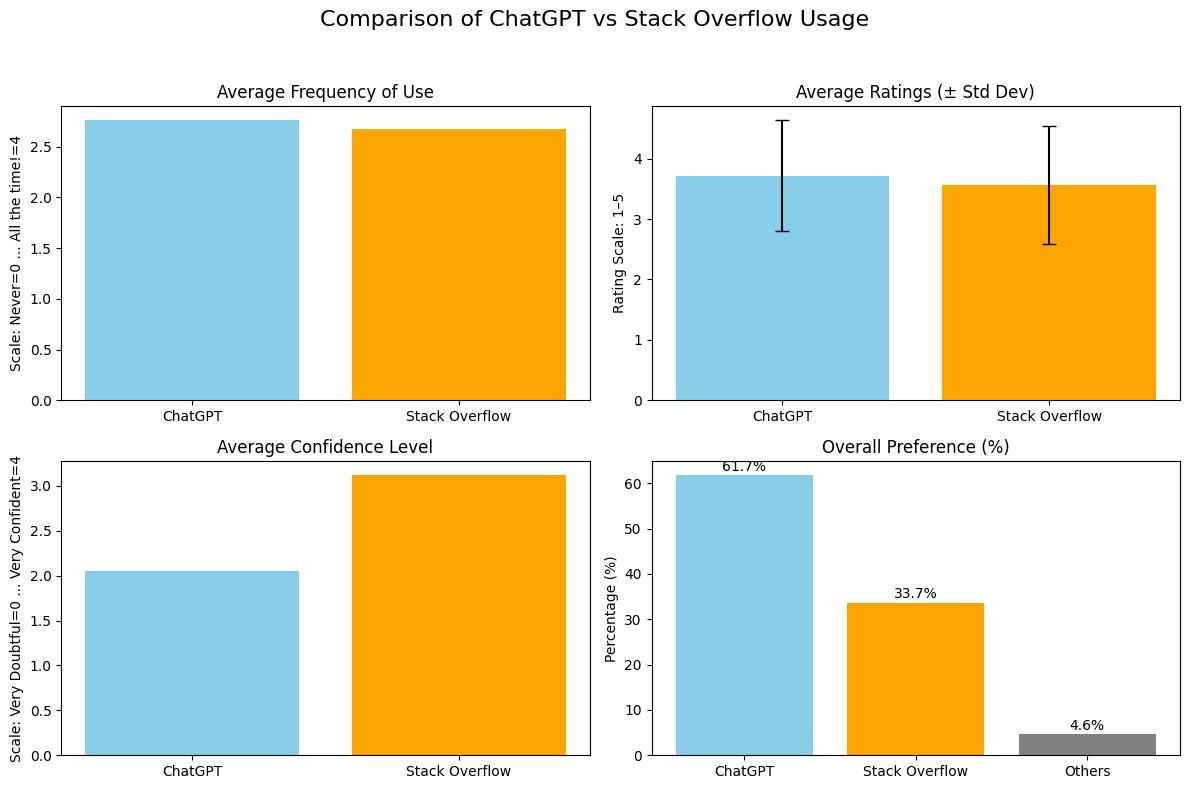

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("Reviews.csv")

# Define mapping for frequency and confidence levels
freq_map = {
    "Never": 0, "Rarely": 1, "Occasionally": 2,
    "Frequently": 3, "All the time!": 4
}
conf_map = {
    "Very Doubtful": 0, "Somewhat Doubtful": 1, "Neutral": 2,
    "Somewhat Confident": 3, "Very Confident": 4
}

# Map values to numeric
df["FCG_num"] = df["FCG"].map(freq_map)
df["FSO_num"] = df["FSO"].map(freq_map)
df["CCG_num"] = df["CCG"].map(conf_map)
df["CSO_num"] = df["CSO"].map(conf_map)

# Normalize preference categories
df["PREFERENCE_CLEAN"] = df["PREFERENCE"].apply(
    lambda x: x if x in ["ChatGPT", "Stack Overflow"] else "Others"
)

# Set up figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Comparison of ChatGPT vs Stack Overflow Usage", fontsize=16)

# --- 1. Frequency of Use ---
axes[0, 0].bar(["ChatGPT", "Stack Overflow"],
               [df["FCG_num"].mean(), df["FSO_num"].mean()],
               color=["skyblue", "orange"])
axes[0, 0].set_title("Average Frequency of Use")
axes[0, 0].set_ylabel("Scale: Never=0 ... All the time!=4")

# --- 2. Ratings (Bar chart with error bars) ---
ratings_means = [df["RCG"].mean(), df["RSO"].mean()]
ratings_std = [df["RCG"].std(), df["RSO"].std()]
axes[0, 1].bar(["ChatGPT", "Stack Overflow"],
               ratings_means, yerr=ratings_std,
               capsize=5, color=["skyblue", "orange"])
axes[0, 1].set_title("Average Ratings (± Std Dev)")
axes[0, 1].set_ylabel("Rating Scale: 1–5")

# --- 3. Confidence Levels ---
axes[1, 0].bar(["ChatGPT", "Stack Overflow"],
               [df["CCG_num"].mean(), df["CSO_num"].mean()],
               color=["skyblue", "orange"])
axes[1, 0].set_title("Average Confidence Level")
axes[1, 0].set_ylabel("Scale: Very Doubtful=0 ... Very Confident=4")

# --- 4. Preference (in % instead of counts) ---
pref_counts = df["PREFERENCE_CLEAN"].value_counts(normalize=True) * 100
axes[1, 1].bar(pref_counts.index, pref_counts.values,
               color=["skyblue", "orange", "gray"])
axes[1, 1].set_title("Overall Preference (%)")
axes[1, 1].set_ylabel("Percentage (%)")

# Add percentage labels on bars
for i, val in enumerate(pref_counts.values):
    axes[1, 1].text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv("Reviews.csv")

# Define mapping for frequency and confidence levels
freq_map = {
    "Never": 0, "Rarely": 1, "Occasionally": 2,
    "Frequently": 3, "All the time!": 4
}
conf_map = {
    "Very Doubtful": 0, "Somewhat Doubtful": 1, "Neutral": 2,
    "Somewhat Confident": 3, "Very Confident": 4
}

# Map values to numeric
df["FCG_num"] = df["FCG"].map(freq_map)
df["FSO_num"] = df["FSO"].map(freq_map)
df["CCG_num"] = df["CCG"].map(conf_map)
df["CSO_num"] = df["CSO"].map(conf_map)

# Clean up preference column
df["PREFERENCE_CLEAN"] = df["PREFERENCE"].apply(
    lambda x: x if x in ["ChatGPT", "Stack Overflow"] else "Others"
)

# Create statistics table
stats_data = {
    "Metric": ["Frequency (ChatGPT)", "Frequency (SO)",
               "Rating (ChatGPT)", "Rating (SO)",
               "Confidence (ChatGPT)", "Confidence (SO)"],
    "Mean": [
        df["FCG_num"].mean(),
        df["FSO_num"].mean(),
        df["RCG"].mean(),
        df["RSO"].mean(),
        df["CCG_num"].mean(),
        df["CSO_num"].mean()
    ],
    "Std Dev": [
        df["FCG_num"].std(),
        df["FSO_num"].std(),
        df["RCG"].std(),
        df["RSO"].std(),
        df["CCG_num"].std(),
        df["CSO_num"].std()
    ]
}

stats_df = pd.DataFrame(stats_data)

# Add preference counts separately
pref_counts = df["PREFERENCE_CLEAN"].value_counts().reset_index()
pref_counts.columns = ["Preference", "Count"]

print("\n=== Summary Statistics ===")
print(stats_df.round(2))
print("\n=== Preference Counts ===")
print(pref_counts)

# Save tables to CSV if needed
stats_df.to_csv("summary_statistics.csv", index=False)
pref_counts.to_csv("preference_counts.csv", index=False)



=== Summary Statistics ===
                 Metric  Mean  Std Dev
0   Frequency (ChatGPT)  2.76     0.88
1        Frequency (SO)  2.68     0.83
2      Rating (ChatGPT)  3.72     0.92
3           Rating (SO)  3.57     0.98
4  Confidence (ChatGPT)  2.05     1.01
5       Confidence (SO)  3.12     0.77

=== Preference Counts ===
       Preference  Count
0         ChatGPT    121
1  Stack Overflow     66
2          Others      9


In [ ]:
import pandas as pd

# Load CSV (replace with your file name)
df = pd.read_csv("Labelled.csv")

# Step 1: Show unique values in each category column
print("\n=== Unique Values in Columns ===")
for col in ["Preference", "Overall Sentiment", "Extended Sentiment", "Additional Notes"]:
    unique_vals = df[col].dropna().unique()
    print(f"\n{col} ({len(unique_vals)} unique):")
    print(unique_vals)

# Step 2: Count occurrences
pref_counts = df["Preference"].value_counts(dropna=False)
sent_counts = df["Overall Sentiment"].value_counts(dropna=False)
ext_sent_counts = df["Extended Sentiment"].value_counts(dropna=False)
notes_counts = df["Additional Notes"].value_counts(dropna=False)

# Step 3: Build summary table with counts & percentages
summary_data = {
    "Metric": [
        "Total Comments",
        "Preference: ChatGPT",
        "Preference: Stack Overflow",
        "Preference: Others/None",
        "Sentiment: Positive",
        "Sentiment: Negative",
        "Sentiment: Neutral",
        "Extended: Caution",
        "Extended: Concern",
        "Extended: Toxic",
        "Extended: Other",
        "Has Additional Notes",
        "No Additional Notes"
    ],
    "Count": [
        len(df),
        pref_counts.get("ChatGPT", 0),
        pref_counts.get("Stack Overflow", 0),
        len(df) - (pref_counts.get("ChatGPT", 0) + pref_counts.get("Stack Overflow", 0)),
        sent_counts.get("Positive", 0),
        sent_counts.get("Negative", 0),
        sent_counts.get("Neutral", 0),
        ext_sent_counts.get("Caution", 0),
        ext_sent_counts.get("Concern", 0),
        ext_sent_counts.get("Toxic", 0),
        len(df) - (ext_sent_counts.get("Caution", 0) + ext_sent_counts.get("Concern", 0) + ext_sent_counts.get("Toxic", 0)),
        df["Additional Notes"].notna().sum(),
        df["Additional Notes"].isna().sum()
    ]
}

# Add percentages
summary_df = pd.DataFrame(summary_data)
summary_df["Percentage"] = (summary_df["Count"] / len(df) * 100).round(1)

# Step 4: Display summary table
print("\n=== Summary Table ===")
print(summary_df)

# Step 5: Save for later use in the research paper
summary_df.to_csv("sentiment_summary.csv", index=False)



=== Unique Values in Columns ===

Preference (9 unique):
['SO' 'ChatGPT' 'Not clear' 'Neither' 'Both' 'neither' 'both' 'not clear'
 'so']

Overall Sentiment (10 unique):
['Negative' 'Positive' 'Neutral' 'Mixed' 'Not clear' 'neutral' 'positive'
 'mixed' 'negative' 'not clear']

Extended Sentiment (268 unique):
['Frustration, Skepticism' 'Humor, Caution' 'Affirmation' 'Frustration'
 'Caution' 'Curiosity' 'Relief' 'Relief, Caution' 'Joy, Surprise' 'Toxic'
 'Joy' 'Sarcastic' 'caution' 'Curiosity, Concern' 'Rude, Frustration'
 'Rude' 'Concern' 'Joy, Caution' 'Caution, relief' 'Abusive, Toxic'
 'Pragmatism' 'Caution, Frustration' 'Optimistic, Disagreement'
 'Frustration, Caution' 'Warning' 'caution, surprise' 'Humor, Affirmation'
 'Joy, Defending' 'Sarcastic, Frustation' 'Relief, Joy'
 'Confidence, Sarcasm' 'Frustration, Pragmatism' 'Pragmatism, Joy'
 'pragmatism, caution' 'Frustration, Pessimistic'
 'Frustration, Disagreement' 'Frustration, Disapproval of AI, Pessimism'
 'Frustration, clar

In [ ]:
import pandas as pd
import re

# Load CSV
df = pd.read_csv("Labelled.csv")

# --- 1. Clean Preference column ---
def clean_preference(val):
    if pd.isna(val):
        return None
    val_lower = val.strip().lower()
    if val_lower in ["so", "stack overflow"]:
        return "Stack Overflow"
    elif val_lower == "chatgpt":
        return "ChatGPT"
    elif val_lower == "both":
        return "Both"
    else:
        return None  # Ignore 'neither', 'not clear', etc.

df["Preference_Clean"] = df["Preference"].apply(clean_preference)

# --- 2. Clean Overall Sentiment ---
def clean_sentiment(val):
    if pd.isna(val):
        return None
    val_lower = val.strip().lower()
    if val_lower == "negative":
        return "Negative"
    elif val_lower == "positive":
        return "Positive"
    else:
        return None  # Ignore neutral, mixed, etc.

df["Sentiment_Clean"] = df["Overall Sentiment"].apply(clean_sentiment)

# --- 3. Categorize Additional Notes ---
def categorize_notes(text):
    categories = []
    if pd.isna(text):
        return categories
    t = text.lower()
    if "usecase" in t or "technical details" in t:
        categories.append("Usecase/Technical")
    if "criticism of chatgpt" in t or "critique of chatgpt" in t:
        categories.append("Critique of ChatGPT")
    if "negative experience of so" in t:
        categories.append("Negative SO Experience")
    if "insensitive" in t or "indescent" in t:
        categories.append("Insensitive/Indecent Behavior")
    if "policy discussion" in t:
        categories.append("Policy Discussion")
    if "detailed analysis" in t:
        categories.append("Detailed Analysis")
    return list(set(categories))  # remove duplicates

df["Notes_Categories"] = df["Additional Notes"].apply(categorize_notes)

# --- 4. Count occurrences ---
# Preference counts
pref_counts = df["Preference_Clean"].value_counts()

# Sentiment counts
sent_counts = df["Sentiment_Clean"].value_counts()

# Notes category counts (multi-label)
from collections import Counter
notes_counter = Counter()
for cats in df["Notes_Categories"]:
    notes_counter.update(cats)

notes_counts_df = pd.DataFrame(notes_counter.items(), columns=["Category", "Count"])
notes_counts_df["Percentage"] = (notes_counts_df["Count"] / len(df) * 100).round(1)

# --- 5. Final Summary Table ---
summary_df = pd.DataFrame({
    "Metric": ["Preference: ChatGPT", "Preference: Stack Overflow", "Preference: Both",
               "Sentiment: Positive", "Sentiment: Negative"],
    "Count": [
        pref_counts.get("ChatGPT", 0),
        pref_counts.get("Stack Overflow", 0),
        pref_counts.get("Both", 0),
        sent_counts.get("Positive", 0),
        sent_counts.get("Negative", 0)
    ]
})
summary_df["Percentage"] = (summary_df["Count"] / len(df) * 100).round(1)

print("\n=== Summary Table ===")
print(summary_df)

print("\n=== Additional Notes Category Counts ===")
print(notes_counts_df)

# Save both tables
summary_df.to_csv("sentiment_summary_clean.csv", index=False)
notes_counts_df.to_csv("notes_category_counts.csv", index=False)



=== Summary Table ===
                       Metric  Count  Percentage
0         Preference: ChatGPT    387        38.7
1  Preference: Stack Overflow    212        21.2
2            Preference: Both     39         3.9
3         Sentiment: Positive    257        25.7
4         Sentiment: Negative    420        42.0

=== Additional Notes Category Counts ===
                        Category  Count  Percentage
0         Negative SO Experience    331        33.1
1              Usecase/Technical    109        10.9
2  Insensitive/Indecent Behavior     53         5.3
3              Detailed Analysis      7         0.7
4            Critique of ChatGPT     76         7.6
5              Policy Discussion      4         0.4


In [ ]:
import pandas as pd
import re

# Load CSV
df = pd.read_csv("Labelled.csv")

# -------------------------
# Step 1: Normalize Preference
# -------------------------
def normalize_pref(val):
    if pd.isna(val):
        return "Other/None"
    val = str(val).strip().lower()
    if val in ["so", "stack overflow"]:
        return "Stack Overflow"
    elif val == "chatgpt":
        return "ChatGPT"
    elif val in ["both"]:
        return "Both"
    else:
        return "Other/None"

df["Preference_Clean"] = df["Preference"].apply(normalize_pref)

# -------------------------
# Step 2: Normalize Overall Sentiment
# -------------------------
def normalize_sentiment(val):
    if pd.isna(val):
        return "Other/None"
    val = str(val).strip().lower()
    if val == "negative":
        return "Negative"
    elif val == "positive":
        return "Positive"
    else:
        return "Other/None"

df["Sentiment_Clean"] = df["Overall Sentiment"].apply(normalize_sentiment)

# -------------------------
# Step 3: Group Additional Notes
# -------------------------
def categorize_notes(note):
    categories = []
    if pd.isna(note):
        return []
    note_lower = note.lower()
    if "usecase" in note_lower or "technical" in note_lower:
        categories.append("Technical/Usecase")
    if "critique" in note_lower or "criticsm" in note_lower or "criticism" in note_lower:
        categories.append("Critique of ChatGPT")
    return categories

df["Notes_Categories"] = df["Additional Notes"].apply(categorize_notes)

# Count how many rows fall into each category (can belong to multiple)
notes_counts = {
    "Technical/Usecase": sum(df["Notes_Categories"].apply(lambda x: "Technical/Usecase" in x)),
    "Critique of ChatGPT": sum(df["Notes_Categories"].apply(lambda x: "Critique of ChatGPT" in x)),
}

# -------------------------
# Step 4: Group Extended Sentiment
# -------------------------
def categorize_extended_sentiment(val):
    if pd.isna(val):
        return "Other"
    val_lower = val.lower()
    if any(word in val_lower for word in ["caution", "skeptic", "warning", "concern"]):
        return "Caution/Skeptical"
    elif any(word in val_lower for word in ["frustration", "angry", "toxic", "insensitive", "hate", "critic"]):
        return "Frustration/Anger"
    elif any(word in val_lower for word in ["praise", "joy", "optimistic", "positive", "hope", "curiosity"]):
        return "Positive/Optimistic"
    else:
        return "Other"

df["Extended_Group"] = df["Extended Sentiment"].apply(categorize_extended_sentiment)

# -------------------------
# Step 5: Build Summary Table
# -------------------------
summary_data = {
    "Metric": [
        "Total Comments",
        "Preference: ChatGPT",
        "Preference: Stack Overflow",
        "Preference: Both",
        "Preference: Other/None",
        "Sentiment: Positive",
        "Sentiment: Negative",
        "Sentiment: Other/None",
        "Notes: Technical/Usecase",
        "Notes: Critique of ChatGPT",
        "Extended: Caution/Skeptical",
        "Extended: Frustration/Anger",
        "Extended: Positive/Optimistic",
        "Extended: Other"
    ],
    "Count": [
        len(df),
        (df["Preference_Clean"] == "ChatGPT").sum(),
        (df["Preference_Clean"] == "Stack Overflow").sum(),
        (df["Preference_Clean"] == "Both").sum(),
        (df["Preference_Clean"] == "Other/None").sum(),
        (df["Sentiment_Clean"] == "Positive").sum(),
        (df["Sentiment_Clean"] == "Negative").sum(),
        (df["Sentiment_Clean"] == "Other/None").sum(),
        notes_counts["Technical/Usecase"],
        notes_counts["Critique of ChatGPT"],
        (df["Extended_Group"] == "Caution/Skeptical").sum(),
        (df["Extended_Group"] == "Frustration/Anger").sum(),
        (df["Extended_Group"] == "Positive/Optimistic").sum(),
        (df["Extended_Group"] == "Other").sum()
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df["Percentage"] = (summary_df["Count"] / len(df) * 100).round(1)

# -------------------------
# Output
# -------------------------
print("\n=== Summary Table ===")
print(summary_df)

summary_df.to_csv("sentiment_clean_summary.csv", index=False)



=== Summary Table ===
                           Metric  Count  Percentage
0                  Total Comments    999       100.0
1             Preference: ChatGPT    387        38.7
2      Preference: Stack Overflow    212        21.2
3                Preference: Both     39         3.9
4          Preference: Other/None    361        36.1
5             Sentiment: Positive    257        25.7
6             Sentiment: Negative    420        42.0
7           Sentiment: Other/None    322        32.2
8        Notes: Technical/Usecase    109        10.9
9      Notes: Critique of ChatGPT     79         7.9
10    Extended: Caution/Skeptical    194        19.4
11    Extended: Frustration/Anger    275        27.5
12  Extended: Positive/Optimistic     64         6.4
13                Extended: Other    466        46.6


In [ ]:
import pandas as pd
import re

# Load CSV
df = pd.read_csv("Labelled.csv")

# -------------------------------
# 1. Clean Preference
# -------------------------------
pref_map = {
    "SO": "Stack Overflow",
    "so": "Stack Overflow",
    "ChatGPT": "ChatGPT",
    "Both": "Both",
    "both": "Both"
}
df["Preference_Clean"] = df["Preference"].map(pref_map)
df_pref_filtered = df[df["Preference_Clean"].notna()]  # drop ignored ones

# -------------------------------
# 2. Clean Overall Sentiment
# -------------------------------
sent_map = {
    "Negative": "Negative",
    "negative": "Negative",
    "Positive": "Positive",
    "positive": "Positive"
}
df["Sentiment_Clean"] = df["Overall Sentiment"].map(sent_map)
df_sent_filtered = df[df["Sentiment_Clean"].notna()]  # drop ignored ones

# -------------------------------
# 3. Additional Notes grouping
# -------------------------------
def categorize_notes(note):
    categories = []
    if pd.isna(note):
        return categories
    text = note.lower()
    if "usecase" in text or "technical" in text:
        categories.append("Usecase/Technical")
    if "criticism" in text or "criticsm" in text or "critique" in text:
        categories.append("Criticism of ChatGPT")
    return categories

df["Notes_Categories"] = df["Additional Notes"].apply(categorize_notes)

# -------------------------------
# 4. Extended Sentiment grouping
# -------------------------------
def categorize_extended(text):
    categories = []
    if pd.isna(text):
        return categories
    t = text.lower()
    if any(word in t for word in ["caution", "skeptic", "warning"]):
        categories.append("Caution/Skepticism")
    if any(word in t for word in ["frustration", "angry", "toxic", "hate", "annoy"]):
        categories.append("Frustration/Negative")
    if any(word in t for word in ["optimistic", "praise", "joy", "happy", "appreciate", "support"]):
        categories.append("Optimism/Praise")
    return categories

df["Extended_Categories"] = df["Extended Sentiment"].apply(categorize_extended)

# -------------------------------
# 5. Create Summary Stats
# -------------------------------
summary_rows = []
total_comments = len(df)

# Preferences
for pref in ["ChatGPT", "Stack Overflow", "Both"]:
    subset = df_pref_filtered[df_pref_filtered["Preference_Clean"] == pref]
    if len(subset) > 0:
        summary_rows.append({
            "Category": f"Preference: {pref}",
            "Count": len(subset),
            "Percentage": round(len(subset) / total_comments * 100, 1),
            "Example Comment": subset.iloc[0]["Comment"]
        })

# Sentiments
for sent in ["Positive", "Negative"]:
    subset = df_sent_filtered[df_sent_filtered["Sentiment_Clean"] == sent]
    if len(subset) > 0:
        summary_rows.append({
            "Category": f"Sentiment: {sent}",
            "Count": len(subset),
            "Percentage": round(len(subset) / total_comments * 100, 1),
            "Example Comment": subset.iloc[0]["Comment"]
        })

# Notes categories
for cat in ["Usecase/Technical", "Criticism of ChatGPT"]:
    subset = df[df["Notes_Categories"].apply(lambda x: cat in x)]
    if len(subset) > 0:
        summary_rows.append({
            "Category": f"Additional Notes: {cat}",
            "Count": len(subset),
            "Percentage": round(len(subset) / total_comments * 100, 1),
            "Example Comment": subset.iloc[0]["Comment"]
        })

# Extended sentiment categories
for cat in ["Caution/Skepticism", "Frustration/Negative", "Optimism/Praise"]:
    subset = df[df["Extended_Categories"].apply(lambda x: cat in x)]
    if len(subset) > 0:
        summary_rows.append({
            "Category": f"Extended Sentiment: {cat}",
            "Count": len(subset),
            "Percentage": round(len(subset) / total_comments * 100, 1),
            "Example Comment": subset.iloc[0]["Comment"]
        })

# Create final summary table
summary_df = pd.DataFrame(summary_rows)

# Save for paper use
summary_df.to_csv("developer_sentiment_summary.csv", index=False)

print(summary_df)


                                   Category  Count  Percentage  \
0                       Preference: ChatGPT    387        38.7   
1                Preference: Stack Overflow    212        21.2   
2                          Preference: Both     39         3.9   
3                       Sentiment: Positive    257        25.7   
4                       Sentiment: Negative    420        42.0   
5       Additional Notes: Usecase/Technical    109        10.9   
6    Additional Notes: Criticism of ChatGPT     79         7.9   
7    Extended Sentiment: Caution/Skepticism    147        14.7   
8  Extended Sentiment: Frustration/Negative    310        31.0   
9       Extended Sentiment: Optimism/Praise    107        10.7   

                                     Example Comment  
0  Going to go against the flow and say it is pre...  
1  So far every technical question I've given it ...  
2  I use booth. I also created a subreddit focuse...  
3  Going to go against the flow and say it is pre... 

In [ ]:
import pandas as pd

# === Step 1: Read CSV ===
file_path = "Labelled.csv"  # Change to your file path
df = pd.read_csv(file_path)

# === Step 2: Show unique values per column ===
print("\nUnique values per column:")
for col in df.columns:
    unique_vals = df[col].dropna().unique()
    print(f"{col}: {unique_vals}")

# === Step 3: Count frequencies for each column (excluding Comment) ===
stats = {}

# Count preferences (grouping uncommon into 'Others/None')
pref_counts = df['Preference'].fillna('None').value_counts()
stats['Preference'] = pref_counts

# Count overall sentiment
sent_counts = df['Overall Sentiment'].fillna('None').value_counts()
stats['Overall Sentiment'] = sent_counts

# Count extended sentiment
ext_sent_counts = df['Extended Sentiment'].fillna('None').value_counts()
stats['Extended Sentiment'] = ext_sent_counts

# Count additional notes
notes_counts = df['Additional Notes'].fillna('None').value_counts()
stats['Additional Notes'] = notes_counts

# === Step 4: Create final summary table dataframe ===
summary_df = pd.DataFrame({
    "Category": [],
    "Value": [],
    "Count": []
})

for category, counts in stats.items():
    for val, count in counts.items():
        summary_df = pd.concat([
            summary_df,
            pd.DataFrame({"Category": [category], "Value": [val], "Count": [count]})
        ], ignore_index=True)

# Save summary table
summary_df.to_csv("summary_statistics.csv", index=False)
print("\nSummary Table:")
print(summary_df)

# === Step 5: Generate LaTeX table ===
latex_table = summary_df.to_latex(index=False, caption="Developer Sentiments and Preferences towards AI Tool Usage", label="tab:sentiments")
with open("summary_table.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)

print("\nLaTeX table code saved to summary_table.tex")



Unique values per column:
Comment: ["So far every technical question I've given it to solve some niche issue, it's failed 100% to get anywhere near a right solution.  It's also generated very terrible code if asked to do something that would take more than a few lines.\n\nBut if you're asking how to do a loop or something in some dialect, fire away.\n\nSo use it on easy stuff.  It's a long way from being able to innovate and be in your problem space.\n\nIf you ask it for something and you don't routinely use it, you'll likely forget about the details anyhow even if you'd used SO."
 'Going to go against the flow and say it is pretty good as an alternative for stack overflow. If you can’t get it to give you working code snippets, you should work on your prompts. No, it can’t create novel solutions to your problem, but 99.9999% of the time, your problem is not unique. So you can actually do a whole lot with it. That being said, try to understand the code it’s giving you. You can even ask